# __Symmetry analysis. Pysical adequacy__

### __Calculators definitions__

In [1]:
# ANI


# import the calculators
from torch import device
from torchani.models import ANI1x, ANI2x, ANI1ccx

ani1x_calc = ANI1x().ase()
ani1ccx_calc = ANI1ccx().ase()
ani2x_calc = ANI2x().ase()

# device type can defined via torch and parsed to the model via .to() method
#device_ = device('cpu')
#model_ = ANI1x(periodic_table_index=True).to(device_).double().ase()


# MACE
from mace.calculators import mace_mp, mace_off

macemp = mace_mp(
    model="medium", 
    dispersion=False, 
    default_dtype="float32", 
    device='cpu',
    )

maceoff = mace_off(
    model="medium", 
    device='cpu',
    default_dtype='float32'
    )

# ORB

from orb_models.forcefield.pretrained import orb_v2, orb_d3_v2
from orb_models.forcefield.calculator import ORBCalculator

orbff_v2 = orb_v2(device='cpu')
orb_calc_v2 = ORBCalculator(orbff_v2, device='cpu')

orbff_d3_v2 = orb_d3_v2(device='cpu')
orb_calc_d3_v2 = ORBCalculator(orbff_d3_v2, device='cpu')


CALC_NAME = 'ALL'

/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/aev.py:16: UserWarning: cuaev not installed
  warnings.warn("cuaev not installed")


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/
/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/
/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/torchani/resources/


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indice

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /Users/sergiortizropero/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.
Using MACE-OFF23 MODEL for MACECalculator with /Users/sergiortizropero/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=model_p

Default dtype float32 does not match model dtype float64, converting models to float32.


/Users/sergiortizropero/miniconda3/envs/ASE_all/lib/python3.10/site-packages/orb_models/forcefield/pretrained.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict

In [1]:
# UMA
from fairchem.core import FAIRChemCalculator
from fairchem.core.units.mlip_unit import load_predict_unit

# define the UMA ASE calculator
uma_predictor = load_predict_unit(
    path='/Users/sergiortizropero/TFG_phys/NNPs_TFG/models/ase_uma/uma-s-1p1.pt', 
    device='cpu',                   
    inference_settings='default',   
)
uma_calc = FAIRChemCalculator(
    uma_predictor,
    task_name='omol',               
)

CALC_NAME = 'UMA'

/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/torchtnt/utils/version.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
W0710 20:16:08.155000 27177 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
# define the calculators
calculator_list = [ani1x_calc, ani1ccx_calc, ani2x_calc, macemp, maceoff, orb_calc_v2, orb_calc_d3_v2]
calculator_names = ['ANI-1x', 'ANI-1ccx', 'ANI-2x', 'MACE-MP', 'MACE-OFF', 'ORB-V2', 'ORB-D3-V2']
calculator_colors = ['darkviolet', 'crimson', 'deeppink', 'darkgreen', 'mediumseagreen', 'royalblue', 'darkblue']

color_dict = {
    'ANI-1x': 'darkviolet', 
    'ANI-1ccx': 'crimson', 
    'ANI-2x': 'deeppink', 
    'MACE-MP': 'darkgreen', 
    'MACE-OFF':  'mediumseagreen', 
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
}

In [2]:
# define the calculators
calculator_list = [uma_calc]
calculator_names = ['UMA_small']
calculator_colors = ['black']

color_dict = {
    'UMA_small': 'black', 
}

## __General imports__

In [3]:
# general imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
rc('lines', lw=1, color='b')
rc('legend', loc='best')
plt.rcParams["legend.fancybox"] = False
plt.rcParams["legend.edgecolor"] = 'black'
plt.rcParams['legend.borderpad'] = 0.25
plt.rcParams['legend.fontsize'] = 11
plt.rcParams.update({'pgf.preamble': r'\usepackage{amsmath}'})

from ase import Atoms
from ase.visualize import view
from ase.build import molecule
from ase.io import write, read
from ase.io import Trajectory, trajectory
from ase import build
from ase.data.pubchem import pubchem_atoms_search

In [4]:
def torque(positions, forces):
    torques = []
    for position, force in zip(positions, forces):
        tau = np.cross(position, force)
    torques.append(tau)
    return np.array(torques).sum()


def compute_com_torque(atoms):
    '''
    Compute the total internal torque wrt the center of mass of the molecule
    Note that the total tau is invariant wrt the change of coordinate system. 
    '''
    
    # copy the object (just to be safe)
    molecule = atoms
    molecule.info = {"charge": 0, "spin": 1} 

    # get center of mass
    com = molecule.get_center_of_mass()
    #print(f'initial com\t{com}')

    # get initial torque
    pos = np.array(molecule.get_positions())
    forces = np.array(molecule.get_forces())
    torques = torque(pos, forces)
    #print(f'total torque\t{torques}')

    # substract com to "center" the molecule
    cur_pos = np.array(molecule.positions)
    new_pos = cur_pos - com
    molecule.positions = new_pos

    # get new center of mass
    com_final = molecule.get_center_of_mass()
    #print(f'final com\t{com_final}')

    # get final torque
    pos_prime = np.array(molecule.get_positions())
    forces_prime = np.array(molecule.get_forces())
    torques_prime = torque(pos_prime, forces_prime)
    #print(f'final torque\t{torques}')

    return torques_prime

In [5]:
def evaluate_rotation(molecule, calculator_list, mol_name, calc_name, verbose=False, rot_angle='z', visualize=False, group=[], compute_torque=True, cosan=False, resolution=None, linewidth=1, UMA=False):

    # create the working directory
    work_dir = os.path.join(os.curdir, 'symmetries',  mol_name)
    if not os.path.isdir(work_dir):
        os.makedirs(work_dir)

    # define the trajectory file and path
    if len(calculator_list) == 1:
        traj_path = os.path.join(work_dir, f'{mol_name}_{calc_name}_rotation.traj')
        traj = trajectory.TrajectoryWriter(filename=traj_path, mode='w')

    # fixed resolution
    if resolution is not None:
        delta_angle = resolution
    else: 
        delta_angle = 6.
    points = int(360./delta_angle)
    angles = np.linspace(0., 360., points+1)

    # print a description of the calculation
    print(f'{mol_name}')
    print(f'analyzing {points} rotationally different structures')
    print(f'using {len(calculator_list)} models')
    print(f'scanning angles:\n{angles}')
    
    # initiate a .txt to store the max fluctuations
    fluctuation_path = os.path.join('./symmetries',mol_name,f'{mol_name}_rotation_fluctuations')+'.txt'
    with open(fluctuation_path, 'w') as f:
        f.write(f'# rotation results for {mol_name}\n')
        f.write(f'# MODEL\t\t\tMAX E\t\t\tMAX F\t\t\tMAX tau\n')
    
    # save UMA model data in a separate folder to plot all models (dependency issue)
    uma_file_name = os.path.join('./symmetries',mol_name,f'{mol_name}_UMA_small_data_rotations')+'.txt'
    uma_loaded = False

    # compute rotation energies, forces and torques
    energies = []
    forces = []
    torques = []
    sucessful_calcs = []

    k = 0
    for calc_ in calculator_list:
        k += 1

        #try:

        molecule.calc = calc_
        molecule.info = {"charge": 0, "spin": 1} 
        calc_energy_list = []
        calc_force_list = []
        calc_torque_list = []

        for angle in angles:
            
            energy_ = molecule.get_potential_energy()
            force = np.array(molecule.get_forces())
            f_vec = force.sum(axis=0)
            f_scalar = np.sqrt(f_vec.dot(f_vec))
            if compute_torque:
                calc_torque_list.append(compute_com_torque(molecule))
            calc_energy_list.append(energy_)
            calc_force_list .append(f_scalar)
            
            if verbose:
                print(f'energy ({angle:.0f} deg)\t{energy_}')
            
            if len(calculator_list) == 1:
                traj.write(molecule)

            if len(group) == 0:
                molecule.rotate(delta_angle, rot_angle)
            
            else:
                # perform a group rotation
                subsys = molecule[group]
                subsys.rotate(rot_angle, delta_angle, rotate_cell = False)
                molecule.positions[group] = subsys.positions

        # define relative fluctuations (substracting the minimum)
        idx = np.argmin(calc_energy_list[:])
        min_energy = calc_energy_list[idx]
        corrected_energy = np.array(calc_energy_list[:]) - min_energy
    
        idx_ = np.argmin(calc_force_list[:])
        min_force = calc_force_list[idx_]
        corrected_force = np.array(calc_force_list[:]) - min_force

        if compute_torque:
            idx__ = np.argmin(calc_torque_list[:])
            min_torque = calc_force_list[idx__]
            corrected_torque = np.array(calc_torque_list[:]) - min_torque

        # analysis of each calculator
        idx_energy = np.argmax(corrected_energy)
        idx_force = np.argmax(corrected_force)
        if compute_torque:
            idx_torque = np.argmax(np.array(calc_torque_list[:])-min_torque)
            with open(fluctuation_path, 'a') as f:
                f.write(f'{(calculator_names[k-1])}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\t{corrected_torque[idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\n')

        # save
        energies.append(calc_energy_list)
        forces.append(calc_force_list)
        if compute_torque:
            torques.append(calc_torque_list)

        sucessful_calcs.append(calculator_names[k-1])

        # export raw data of UMA to a .txt file
        if UMA:
            if calc_ == uma_calc:
                with open(file=uma_file_name, mode='w') as f:
                    f.write(f'# UMA data for molecule: {mol_name}\n')
                    f.write(f'# z-axis rotation with {points} rotamers and resolution {resolution}\n')
                    f.write(f'# ENERGY\t\tFORCES\t\tTORQUE (if exists)\n')
                    if compute_torque:
                        for i in range(len(calc_energy_list)):
                            f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\t{corrected_torque[i]}\n')
                    else:
                        for i in range(len(calc_energy_list)):
                            f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\n')
                    
        #except: 
            print(f'CALCULATOR {calculator_names[k-1]} FAILED')

        # visualize the "trajectory" using the built-in ASE visualizer
        if visualize:
            if len(calculator_list) == 1:
                traj = trajectory.TrajectoryReader(traj_path)
                view(traj, viewer='ase')

    #print(f'resulting energies:\n{energies}')
    #print(f'resulting forces (total, scalar):\n{force}')

    # load UMA data, must be obtained in a preprocessing step 
    #if os.path.exists(fluctuation_path): 
    if (not UMA) and os.path.exists(uma_file_name):
        print('loading UMA')
        uma_data = np.loadtxt(delimiter='\t', dtype='float', fname=uma_file_name)
        energies.append(uma_data[:,0])
        forces.append(uma_data[:,1])
        if compute_torque:
            torques.append(uma_data[:,2])
        uma_loaded = True

        # analyze UMA data and append it to the rest 
        idx_energy = np.argmax(uma_data[:,0])
        idx_force = np.argmax(uma_data[:,1])
        if compute_torque:
            idx_torque = np.argmax(uma_data[:,2])
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\t{uma_data[:,2][idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\n')

    # plot the energies
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    
    if cosan:
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")
        ax_twin = plt.twinx(ax)
        ax_twin.tick_params(bottom=False, top=False, left=False, right=True, direction="in")
        ax_twin.tick_params(labelbottom=False, labeltop=False, labelleft=False, labelright=True, direction="in")
        
        plots = []
        for k in range(len(sucessful_calcs)):
            idx = np.argmin(energies[k][:])
            min_energy = energies[k][idx]


            if k == 0:
                p = ax.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=1.0, lw=2)
                plots.append(p)
            else:
                p = ax_twin.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.6)
                plots.append(p)

            ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV) (\textbf{MACE})}$')
            ax_twin.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV) (\textbf{ORB})}$')

        plots_sum = plots[0]+plots[1]+plots[2]
        labs = [p.get_label() for p in plots_sum]
        ax_twin.legend(plots_sum, labs, loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})


    else:
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")
        
        for k in range(len(sucessful_calcs)):
            idx = np.argmin(energies[k][:])
            min_energy = energies[k][idx]
            ax.plot(angles, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.8, lw=linewidth)

        # add UMA data to the plot
        if uma_loaded:
            idx = np.argmin(energies[-1][:])
            min_energy = energies[-1][idx]
            ax.plot(angles, np.array(energies[-1][:])-min_energy, label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.8, lw=linewidth)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\Delta E\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-5, 1e-5)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_energy_rotation.png'), dpi=400)
    plt.show(fig)


    # plot the forces
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(forces[k][:])
        min_energy = forces[k][idx]
        ax.plot(angles, (np.array(forces[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    if uma_loaded:
        idx = np.argmin(forces[-1][:])
        min_force = forces[-1][idx]
        ax.plot(angles, (np.array(forces[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\textnormal{Total forces}\quad\textnormal{(eV/Å)}$')
    # workaround only to avoid displaying very small numbers (truncation errors)
    #ax.set_ylim(-1e-5, 1e-5)
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_forces_rotation.png'), dpi=400)
    plt.show(fig)



    # plot the torques
    if compute_torque:
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

        for k in range(len(sucessful_calcs)):
            idx = np.argmin(torques[k][:])
            min_energy = torques[k][idx]
            ax.plot(angles, (np.array(torques[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

        if uma_loaded:
            print(torques[-1])
            idx = np.argmin(torques[-1][:])
            min_force = torques[-1][idx]
            ax.plot(angles, (np.array(torques[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        ax.set(xlabel=r'$z\textnormal{-axis rotation}\;(\textnormal{deg}\;^\circ)$', ylabel=r'$\textnormal{Total torque}\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-10, 1e-10)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
        
        plt.tight_layout()
        plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_torque_rotation.png'), dpi=400)
        plt.show(fig)   

In [6]:
def evaluate_translation(molecule, calculator_list, mol_name, calc_name, verbose=False, trans_vector=(0,0,1), resolution=0.1, search_space=[-10, 10], visualize=False, compute_torque=True, UMA=False):
    '''
    trans_vector is converted to unitary prior to application!!! (1A displacement resolution)
    search_space is the translation coordinates to explore at `resolution` Å steps
    '''

    # create the working directory
    work_dir = os.path.join(os.curdir, 'symmetries',  mol_name)
    if not os.path.isdir(work_dir):
        os.makedirs(work_dir)

    # define the trajectory file and path
    if len(calculator_list) == 1:
        traj_path = os.path.join(work_dir, f'{mol_name}_{calc_name}_translation.traj')
        traj = trajectory.TrajectoryWriter(filename=traj_path, mode='w')
        
    # compute the unit translation vector 
    vec = np.array(trans_vector)
    unit_transl_vector = vec / (np.sqrt(vec.dot(vec)))

    # adjust for resolution 
    scaled_transl_vector = unit_transl_vector * resolution
    displacements = np.arange(search_space[0], search_space[1]+resolution, step=resolution)

    # print a description of the calculation
    print(f'using unit translation vector\t{unit_transl_vector}')
    print(f'analyzing translationally different structures with resolution {resolution} Å')
    print(f'using {len(calculator_list)} models')
    print(f'scanning total displacements:\n{displacements}')
    
    # initiate a .txt to store the max fluctuations
    fluctuation_path = os.path.join('./symmetries',mol_name,f'{mol_name}_translation_fluctuations')+'.txt'
    with open(fluctuation_path, 'w') as f:
        f.write(f'# translation results for {mol_name}\n')
        f.write(f'# MODEL\t\t\tMAX E\t\t\tMAX F\t\t\tMAX tau\n')
    
    # save UMA model data in a separate folder to plot all models (dependency issue)
    uma_file_name = os.path.join('./symmetries',mol_name,f'{mol_name}_UMA_small_data_translations')+'.txt'
    uma_loaded = False


    # compute translation energies, forces and torques
    energies = []
    forces = []
    torques = []
    sucessful_calcs = []

    k = 0
    for calc_ in calculator_list:
        k += 1

        #try:
        molecule.calc = calc_
        molecule.info = {"charge": 0, "spin": 1} 
        calc_energy_list = []
        calc_force_list = []
        calc_torque_list = []

        for displacement in displacements:
            
            energy_ = molecule.get_potential_energy()
            force = np.array(molecule.get_forces())
            f_vec = force.sum(axis=0)
            f_scalar = np.sqrt(f_vec.dot(f_vec))
            if compute_torque:
                calc_torque_list.append(compute_com_torque(molecule))
            calc_energy_list.append(energy_)
            calc_force_list .append(f_scalar)
            
            if verbose:
                print(f'energy ({displacement:.0f} Å)\t{energy_}')
            
            if len(calculator_list) == 1:
                traj.write(molecule)

            molecule.translate(scaled_transl_vector)
        
        # define relative fluctuations (substracting the minimum)
        idx = np.argmin(calc_energy_list[:])
        min_energy = calc_energy_list[idx]
        corrected_energy = np.array(calc_energy_list[:]) - min_energy
    
        idx_ = np.argmin(calc_force_list[:])
        min_force = calc_force_list[idx_]
        corrected_force = np.array(calc_force_list[:]) - min_force

        if compute_torque:
            idx__ = np.argmin(calc_torque_list[:])
            min_torque = calc_force_list[idx__]
            corrected_torque = np.array(calc_torque_list[:]) - min_torque

        # analysis of each calculator
        idx_energy = np.argmax(corrected_energy)
        idx_force = np.argmax(corrected_force)
        if compute_torque:
            idx_torque = np.argmax(np.array(calc_torque_list[:])-min_torque)
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\t{corrected_torque[idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'{calculator_names[k-1]}\t{corrected_energy[idx_energy]}\t{corrected_force[idx_force]}\n')

        # save 
        energies.append(corrected_energy)
        forces.append(corrected_force)
        if compute_torque:
            torques.append(corrected_torque)

        sucessful_calcs.append(calculator_names[k-1])

        # export raw data of UMA to a .txt file
        if UMA:
            with open(file=uma_file_name, mode='w') as f:
                f.write(f'# UMA data for molecule: {mol_name}\n')
                f.write(f'# translation direction {unit_transl_vector} with resolution {resolution} and {len(displacements)} displacements\n')
                f.write(f'# ENERGY\t\tFORCES\t\tTORQUE (if exists)\n')
                if compute_torque:
                    for i in range(len(calc_energy_list)):
                        f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\t{corrected_torque[i]}\n')
                else:
                    for i in range(len(calc_energy_list)):
                        f.write(f'{corrected_energy[i]}\t{corrected_force[i]}\n')
                
        #except: 
            #print(f'CALCULATOR {calculator_names[k-1]} FAILED')
        
        # visualize the "trajectory" using the built-in ASE visualizer
        if visualize:
            if len(calculator_list) == 1:
                traj = trajectory.TrajectoryReader(traj_path)
                view(traj, viewer='ase')

    #print(f'resulting energies:\n{energies}')
    #print(f'resulting forces (total, scalar):\n{force}')

    # load UMA data, must be obtained in a preprocessing step 
    #if os.path.exists(fluctuation_path): 
    if (not UMA) and os.path.exists(uma_file_name):
        print('loading UMA')
        uma_data = np.loadtxt(delimiter='\t', dtype='float', fname=uma_file_name)
        energies.append(uma_data[:,0])
        forces.append(uma_data[:,1])
        if compute_torque:
            torques.append(uma_data[:,2])
        uma_loaded = True

        # analyze UMA data and append it to the rest 
        idx_energy = np.argmax(uma_data[:,0])
        idx_force = np.argmax(uma_data[:,1])
        if compute_torque:
            idx_torque = np.argmax(uma_data[:,2])
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\t{uma_data[:,2][idx_torque]}\n')
        else:
            with open(fluctuation_path, 'a') as f:
                f.write(f'UMA_small\t{uma_data[:,0][idx_energy]}\t{uma_data[:,1][idx_force]}\n')

    # plot the energies
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(energies[k][:])
        min_energy = energies[k][idx]
        ax.plot(displacements, (np.array(energies[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    # add UMA data to the plot
    if uma_loaded:
        idx = np.argmin(energies[-1][:])
        min_energy = energies[-1][idx]
        ax.plot(displacements, np.array(energies[-1][:])-min_energy, label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\Delta E\quad\textnormal{(eV)}$')
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_energies_translation.png'), dpi=400)
    plt.show(fig)


    # plot the forces
    fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
    ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
    ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

    for k in range(len(sucessful_calcs)):
        idx = np.argmin(forces[k][:])
        min_energy = forces[k][idx]
        ax.plot(displacements, (np.array(forces[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

    if uma_loaded:
        idx = np.argmin(forces[-1][:])
        min_force = forces[-1][idx]
        ax.plot(displacements, (np.array(forces[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

    #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
    ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\textnormal{Total forces}\quad\textnormal{(eV/Å)}$')
    # workaround only to avoid displaying very small numbers (truncation errors)
    #ax.set_ylim(-1e-10, 1e-10)
    ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
    
    plt.tight_layout()
    plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_forces_translation.png'), dpi=400)
    plt.show(fig)


    # plot the torques
    if compute_torque:

        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))
        ax.tick_params(bottom=True, top=True, left=True, right=False, direction="in")
        ax.tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False, direction="in")

        for k in range(len(sucessful_calcs)):
            idx = np.argmin(torques[k][:])
            min_energy = torques[k][idx]
            ax.plot(displacements, (np.array(torques[k][:])-min_energy), label=r'$\textnormal{' + sucessful_calcs[k] + r'}$', color=color_dict[sucessful_calcs[k]], alpha=0.7)

        if uma_loaded:
            print(torques[-1])
            idx = np.argmin(torques[-1][:])
            min_force = torques[-1][idx]
            ax.plot(displacements, (np.array(torques[-1][:])-min_force), label=r'$\textnormal{' + 'UMA_small' + r'}$', color='black', alpha=0.7)

        #'$z\;\textnormal{-axis rotation}\;\textnormal{(deg)}$'
        ax.set(xlabel=r'$v = ' + f'{trans_vector}' + r'\quad\textnormal{translation}\;(\textnormal{Å})$', ylabel=r'$\textnormal{Total torque}\quad\textnormal{(eV)}$')
        # workaround only to avoid displaying very small numbers (truncation errors)
        #ax.set_ylim(-1e-10, 1e-10)
        ax.legend(loc='best', title=f'{mol_name}', title_fontsize='large', prop={'size': 9})
        
        plt.tight_layout()
        plt.savefig(os.path.join(work_dir, f'{mol_name}_{calc_name}_torques_translation.png'), dpi=400)
        plt.show(fig)  


## __ROTATIONS Examples__

water
analyzing 4 rotationally different structures
using 1 models
scanning angles:
[  0.  90. 180. 270. 360.]
CALCULATOR UMA_small FAILED
resulting energies:
[[-2079.862361667363, -2079.8623617269677, -2079.862361667363, -2079.862361741869, -2079.8623616971654]]
resulting forces (total, scalar):
[[-5.1975513e-09  3.1806529e-08 -4.8261946e-01]
 [-4.2130970e-04 -2.2419162e-01  2.4130976e-01]
 [ 4.2131491e-04  2.2419158e-01  2.4130966e-01]]


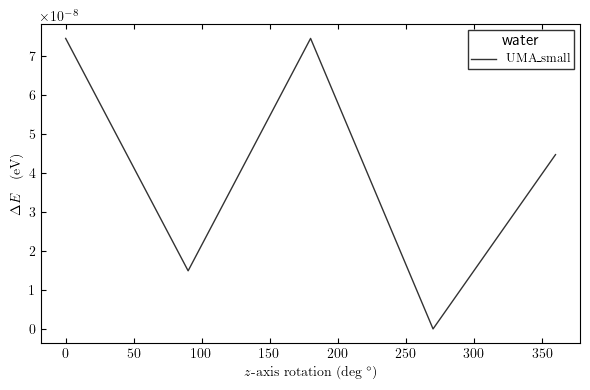

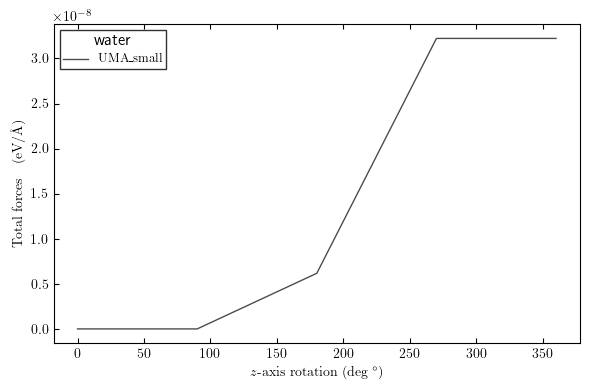

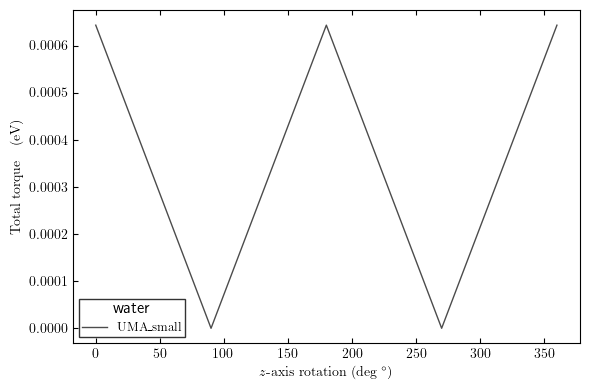

In [144]:
mol_name = 'water'
molecule = build.molecule('H2O')

evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, compute_torque=True, resolution=90)

In [145]:
# export UMA data so that a combined plot with all models can be performed





# return the maximum fluctuation for each model used (via plot function)






# export the E fluctuation
# name  E fluctuation (trans)   F fluct (trans)     T fluct (trans)     E fluct (rot)   F fluct (rot)     T fluct (rot)
# write model and data


# read the UMA data file (UMA.txt)
# modify the plot function to accept UMA model data, else do ANI_all
# join all data and generate the plot





# for each model in a dataset of x molecules:
# compute the average
# compute the exponential average
# print the top 3 max fluctuation and for which molecules
# toggle showing the plot to screen (not needed)

benzene
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

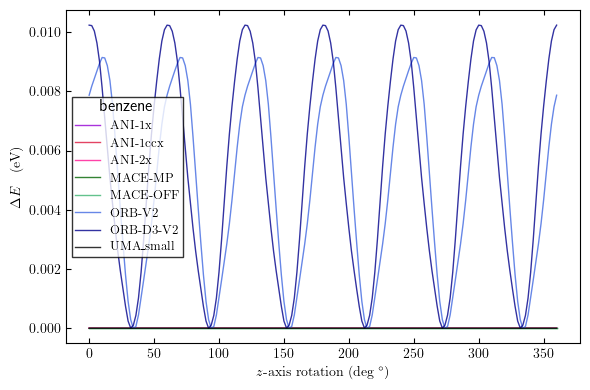

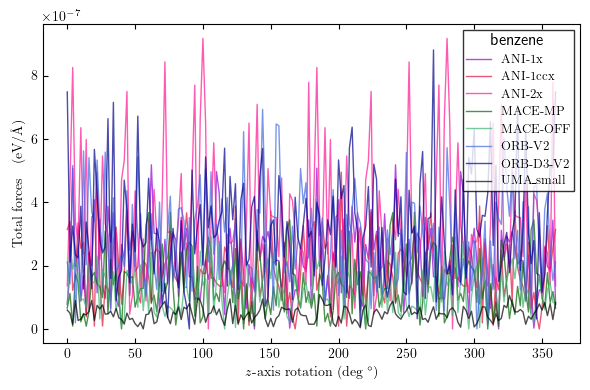

[-2.17371738e-04 -3.76284059e-06 -4.67170863e-06 -2.17999991e-06
 -4.25444257e-06 -1.91452721e-06 -9.40036745e-07 -3.15555457e-06
 -1.54799046e-06 -6.52006034e-07 -1.94757022e-06 -2.46973371e-06
 -1.71605004e-06 -4.51466347e-06  2.74654816e-07 -6.57137245e-07
 -7.58358763e-07  6.31755727e-07 -1.80246648e-06 -2.15839218e-06
  1.78084851e-07 -7.30698876e-07 -6.77404908e-08  4.80790027e-07
 -1.02958219e-06 -1.26020697e-06 -2.49746844e-07 -1.02040311e-06
  1.07734251e-06 -1.63947730e-07  5.50506732e-05 -1.70240507e-06
 -2.25116129e-06 -2.39777862e-06 -2.51102383e-06 -1.11400504e-06
 -2.20904008e-06 -5.70410939e-07 -5.54922848e-07 -4.96736041e-07
  1.25645185e-06 -1.87772991e-06  4.92242387e-07 -1.06950265e-04
 -2.09986950e-07 -1.28383008e-06 -2.40606213e-06 -2.83533722e-06
 -2.49380724e-06 -1.29203021e-06 -3.10388921e-06 -6.66421296e-07
 -1.34560996e-06 -4.86875955e-06 -3.54256494e-06 -2.06124018e-06
 -3.00545379e-06 -8.00186964e-06 -5.37533203e-06 -3.19092769e-06
  1.37358504e-07  4.71903

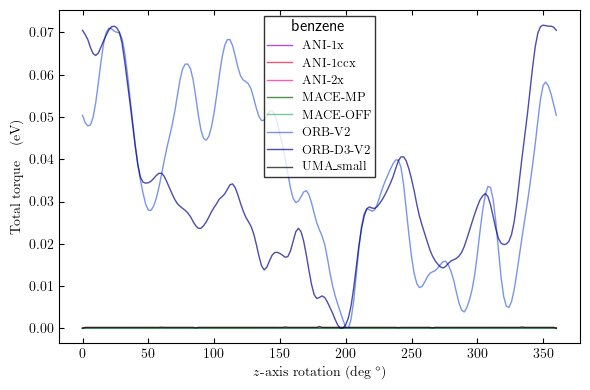

In [11]:
mol_name = 'benzene'
molecule = build.molecule('C6H6')

evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2, compute_torque=True)

ethanol
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

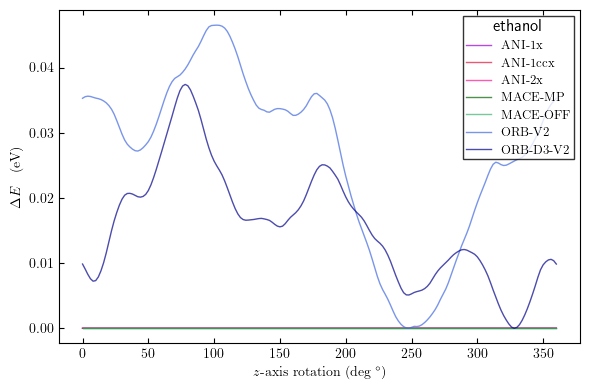

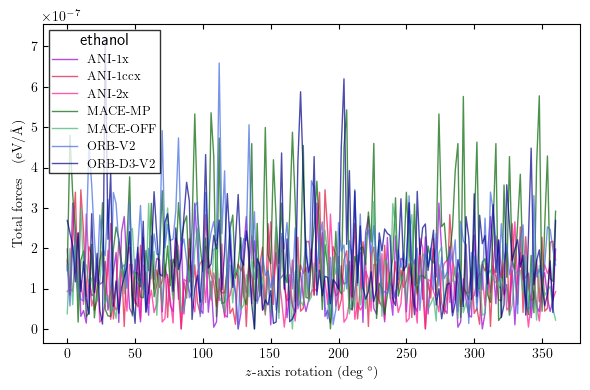

In [13]:
mol_name = 'ethanol'
molecule = build.molecule('CH3CH2OH')

evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2)

cosan
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

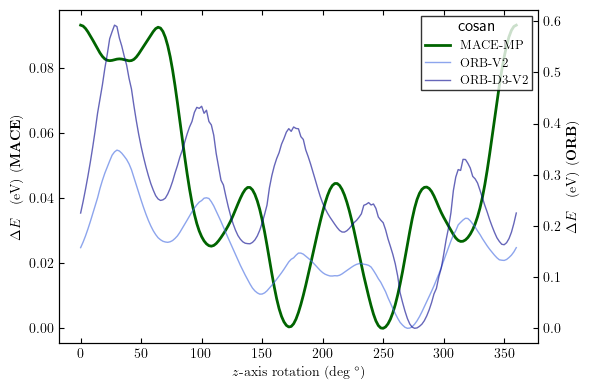

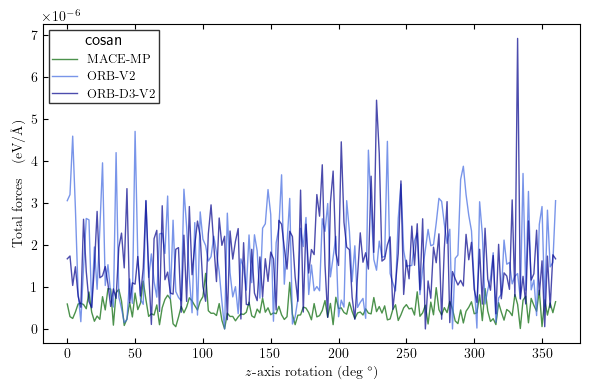

In [15]:
mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)
CALC_NAME='ALL'

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=True, group=group, compute_torque=False, cosan=True, resolution=2)

cosan
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

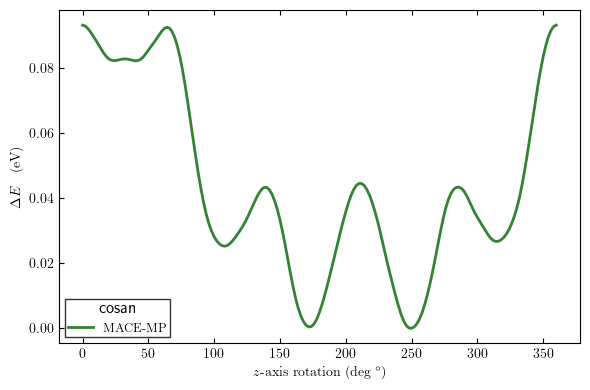

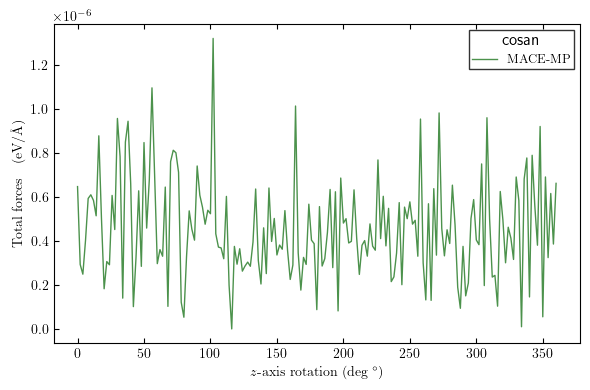

In [16]:
calculator_list = [macemp]
calculator_names = ['MACE-MP']
CALC_NAME='MACE-MP'

mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=False, group=group, compute_torque=False, cosan=False, resolution=2, linewidth=2)

cosan
analyzing 180 rotationally different structures
using 2 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

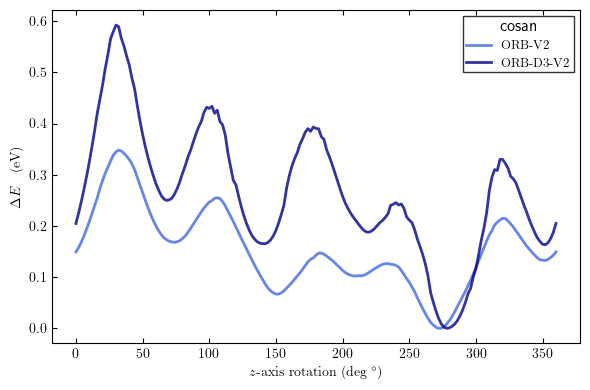

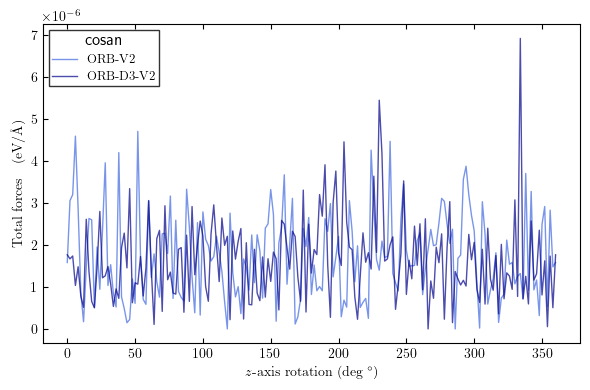

In [17]:
calculator_list = [orb_calc_v2, orb_calc_d3_v2]
calculator_names = ['ORB-V2', 'ORB-D3-V2']
CALC_NAME='ORB'

mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=False, group=group, compute_torque=False, cosan=False, resolution=2, linewidth=2)

cosan
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

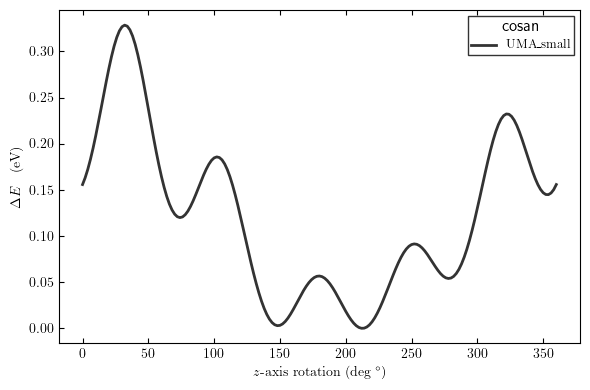

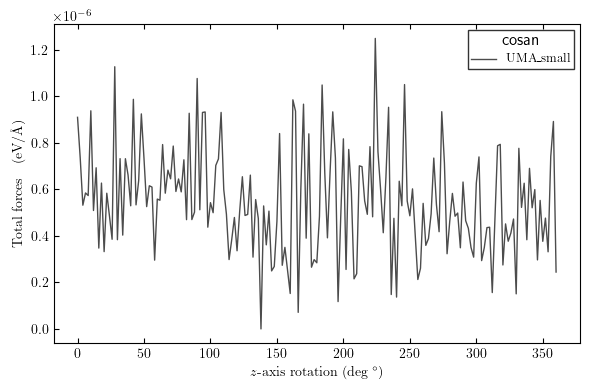

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/matplotlib/pyplot.py", line 614, in show
    return _get_backend_mod().show(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/IPython/core/display_functions.py", line 245, in display
    print(*objs)
ValueError: I/O operati

In [9]:
calculator_list = [uma_calc]
calculator_names = ['UMA_small']
CALC_NAME='UMA_small'


mol_name = 'cosan'
cosan_xyz = '/Users/sergiortizropero/TFG_phys/NNPs_TFG/scripts/symmetry/symmetries/cosan/cosan.xyz'
cosan = read(cosan_xyz)

group = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
evaluate_rotation(cosan, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, visualize=True, group=group, compute_torque=False, cosan=False, resolution=2, linewidth=2)

In [ ]:
# visualize existing traj
work_dir = os.path.join(os.curdir, 'symmetries',  mol_name)
traj_path = os.path.join(work_dir, 'cosan_MACE-MP_rotation.traj')
traj = trajectory.TrajectoryReader(traj_path)

#write(os.path.join(work_dir, 'cosan_MACE-MP_rotation.xyz'), traj)
#view(traj, viewer='ase')

: 

In [14]:
# define the calculators
calculator_list = [ani1x_calc, ani1ccx_calc, ani2x_calc, macemp, maceoff, orb_calc_v2, orb_calc_d3_v2]
calculator_names = ['ANI-1x', 'ANI-1ccx', 'ANI-2x', 'MACE-MP', 'MACE-OFF', 'ORB-V2', 'ORB-D3-V2']
calculator_colors = ['darkviolet', 'crimson', 'deeppink', 'darkgreen', 'mediumseagreen', 'royalblue', 'darkblue']

color_dict = {
    'ANI-1x': 'darkviolet', 
    'ANI-1ccx': 'crimson', 
    'ANI-2x': 'deeppink', 
    'MACE-MP': 'darkgreen', 
    'MACE-OFF':  'mediumseagreen', 
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
}

## __TRANSLATION EXAMPLES__
Check if the energy changes in translations

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4209.111482701035, -4209.111482295554, -4209.1114832078865, -4209.111482194184, -4209.111483410627, -4209.111482092813, -4209.111481788703, -4209.111482092813, -4209.111482295554, -4209.111482802406, -4209.111483410627, -4209.111482295554, -4209.111482701035, -4209.111481890073, -4209.111481890073, -4209.111481687332, -4209.111483106517, -4209.111482802406, -4209.111483309257, -4

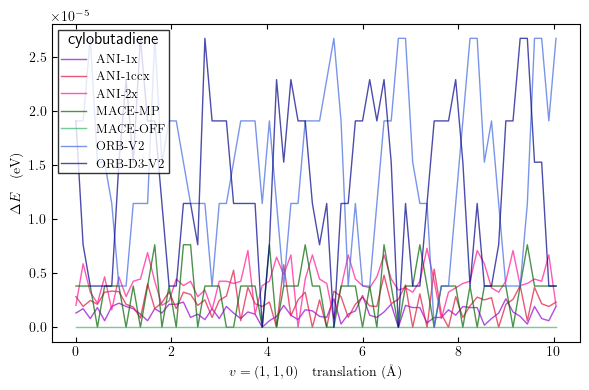

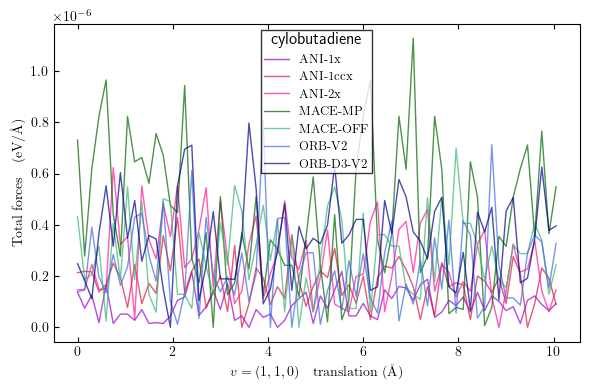

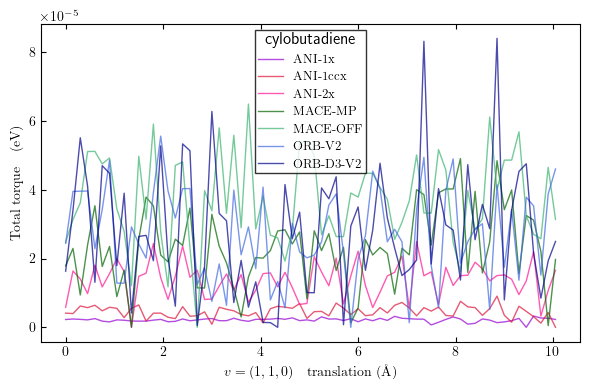

cylobutadiene
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356

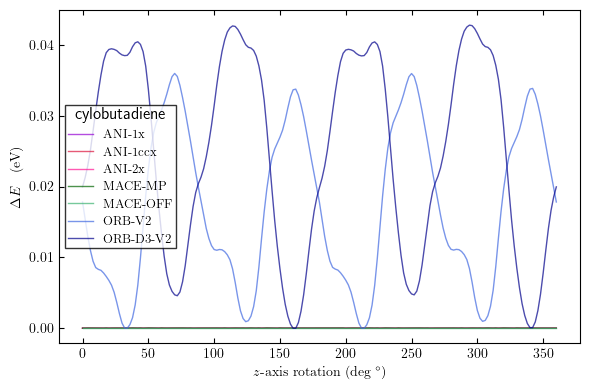

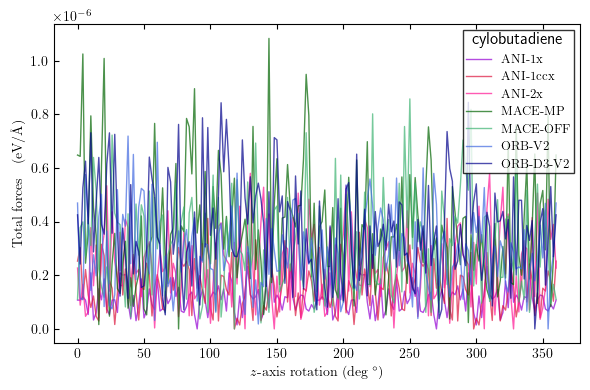

In [ ]:
bond_ids_h = [0, 1]
mask_h = [0, 1, 0, 1, 0, 1, 0, 1]
bond_ids_v = [0, 2]
mask_v = [0, 0, 1, 1, 0, 0, 1, 1]

mol_name = 'cylobutadiene'
bond_name = 'CC'
molecule = pubchem_atoms_search(smiles='C1=CC=C1')

# set C-C distances
molecule.set_distance(bond_ids_h[0], bond_ids_h[1], 1.400000, fix=0, mask=mask_h)
molecule.set_distance(bond_ids_v[0], bond_ids_v[1], 1.400000, fix=0, mask=mask_v)

# set C-H distances
molecule.set_distance(0, 4, 1.08, fix=0)
molecule.set_distance(1, 5, 1.08, fix=0)
molecule.set_distance(2, 6, 1.08, fix=0)
molecule.set_distance(3, 7, 1.08, fix=0)


trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False)
evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-2078.6371570369956, -2078.6371570369956, -2078.6371570369956, -2078.6371570369956, -2078.6371570369956, -2078.6371569863104, -2078.637156935625, -2078.637156960968, -2078.6371570369956, -2078.637157011653, -2078.6371569863104, -2078.637157011653, -2078.6371570369956, -2078.6371569863104, -2078.6371569863104, -2078.637157011653, -2078.637157011653, -2078.637157011653, -2078.637157

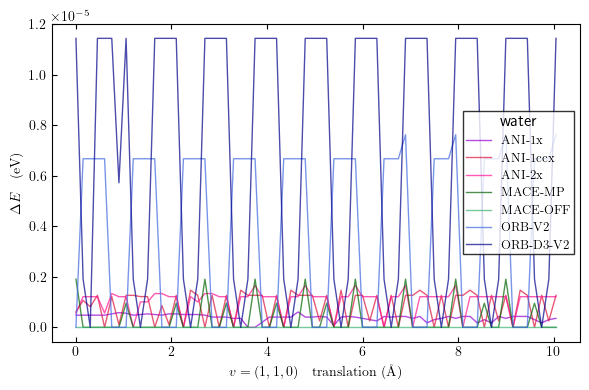

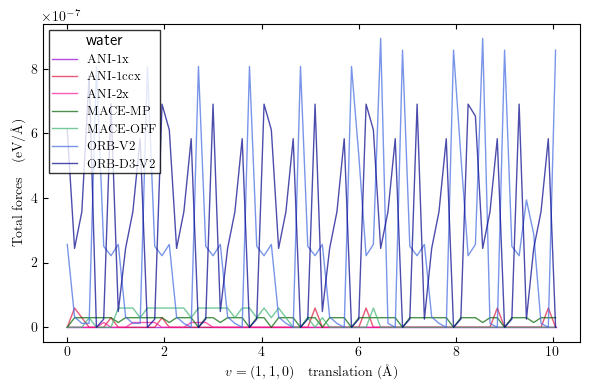

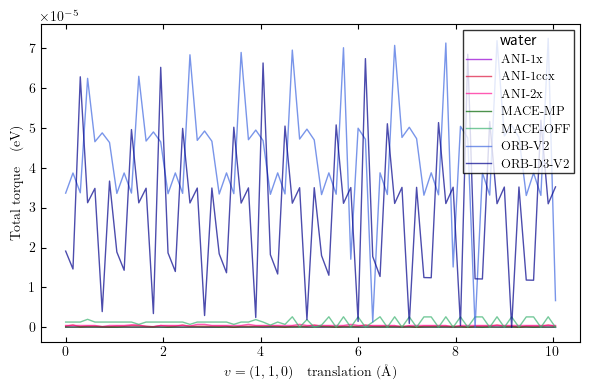

In [9]:
mol_name = 'water'
molecule = build.molecule('H2O')

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-6317.903403291176, -6317.903402074732, -6317.903402480214, -6317.903402277473, -6317.903402480214, -6317.90340146651, -6317.903402277473, -6317.903402074732, -6317.903403088436, -6317.903402885695, -6317.903401871992, -6317.903402480214, -6317.903402277473, -6317.903401669251, -6317.903402480214, -6317.903402074732, -6317.903403088436, -6317.903402074732, -6317.903403493917, -631

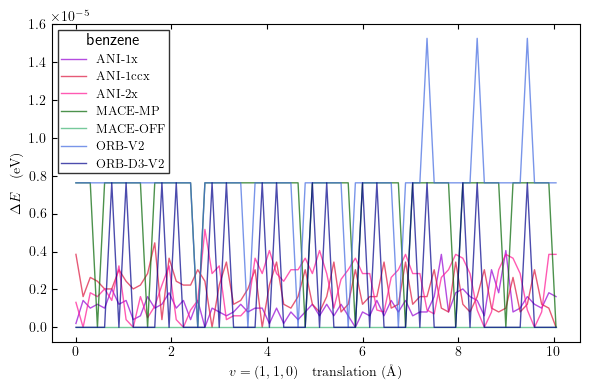

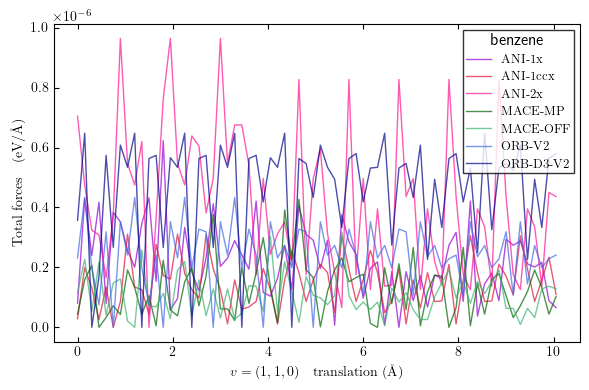

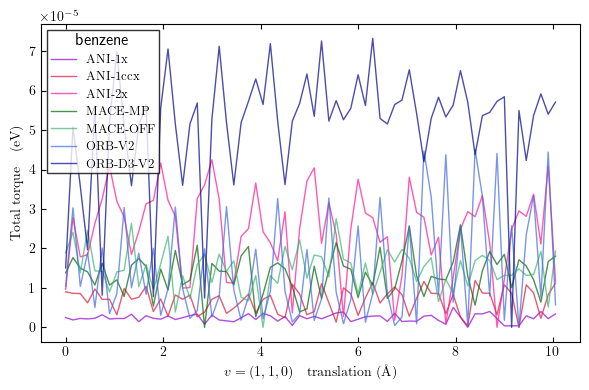

In [11]:
mol_name = 'benzene'
molecule = build.molecule('C6H6')

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4217.496657955742, -4217.496657550261, -4217.496657702317, -4217.496657702317, -4217.496657296836, -4217.496657296836, -4217.496657246151, -4217.496657398206, -4217.496657448891, -4217.496657448891, -4217.496657651632, -4217.496657854373, -4217.496657448891, -4217.496657702317, -4217.496657448891, -4217.496657702317, -4217.496657550261, -4217.49665734752, -4217.496657398206, -421

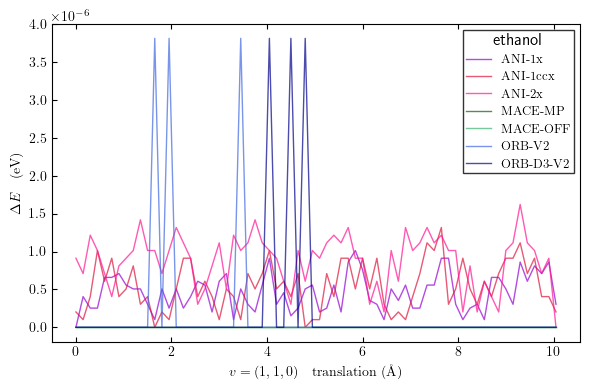

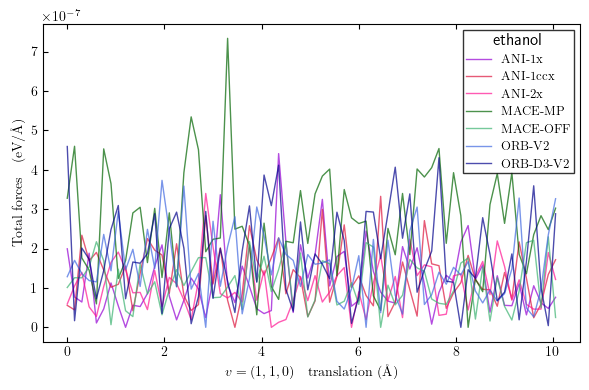

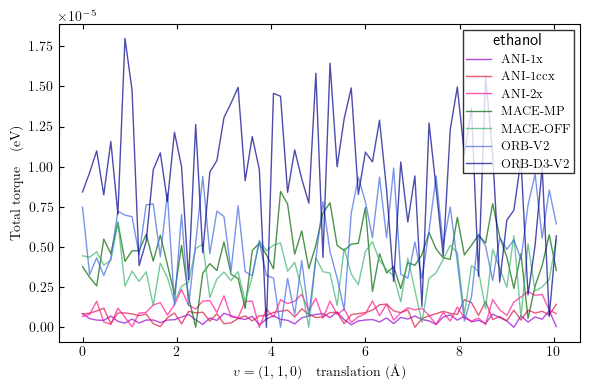

In [12]:
mol_name = 'ethanol'
molecule = build.molecule('CH3CH2OH')

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=True)

## __FORCE TESTING__
Test whether the net force on all the atoms of a given molecule is zero (suma de forces zero). 

In [ ]:
molecule = build.molecule('H2O')
molecule.calc = orb_calc_v2

forces = np.array(molecule.get_forces())

f_vec = forces.sum(axis=0)
f_scalar = np.sqrt(f_vec.dot(f_vec))

## __TORQUE TESTING__

Test whether the net torque is zero (moment de forces zero). The procedure is as follows, compute the center of mass, compute the torques on each particle and add them together. The molecule is centered on the center of mass such that M_R = (0, 0, 0). Torque defined wrt the center of mass. 

These are the classical (rigid body) stationary conditions.

In [ ]:
molecule = build.molecule('CH3CH2OH')
molecule.calc = orb_calc_d3_v2

# per defecte ja està centrat en el center of mass
com = molecule.get_center_of_mass()
print(f'initial com\t{com}')

pos = np.array(molecule.get_positions())
forces = np.array(molecule.get_forces())

torques = []
for i in range(len(pos)):
    tau = np.cross(pos[i], forces[i])
    torques.append(tau)
total_tau = np.array(torques).sum()
print(f'total torque\t{total_tau}')


molecule.center(about=com)
com = molecule.get_center_of_mass()

pos = np.array(molecule.get_positions())
forces = np.array(molecule.get_forces())

print(f'final com after centering\t{com}')


torques = []
for i in range(len(pos)):
    tau = np.cross(pos[i], forces[i])
    torques.append(tau)

total_tau = np.array(torques).sum()
print(f'total torque after centering\t{total_tau}')

initial com	[-5.37767975e-02 -1.86233360e-02  7.30935462e-19]
total torque	-6.24481940603161e-08
final com after centering	[-1.92187595e-01 -1.22383672e-01  7.30935462e-19]
total torque after centering	6.669226297606468e-08


## __Rotational and Translational analysis (energies, forces and torques)__

Create a list with all the molecules of interest to assess the physical adequacy (energy invariance and linear/angular momentum conservation). Results are stored in a folder for each molecule, and a summary is provided with maximum fluctuations. 

Structures are fetched directly from ase, as this is just a qualitative test. 

In [11]:
# define the calculators
#calculator_list = [ani1x_calc, ani1ccx_calc, ani2x_calc, macemp, maceoff, orb_calc_v2, orb_calc_d3_v2, uma_calc]
#calculator_names = ['ANI-1x', 'ANI-1ccx', 'ANI-2x', 'MACE-MP', 'MACE-OFF', 'ORB-V2', 'ORB-D3-V2', 'UMA_small']
#calculator_colors = ['darkviolet', 'crimson', 'deeppink', 'darkgreen', 'mediumseagreen', 'royalblue', 'darkblue', 'black']

calculator_list = [uma_calc]
calculator_names = ['UMA_small']
calculator_colors = ['black']

color_dict = {
    'ANI-1x': 'darkviolet', 
    'ANI-1ccx': 'crimson', 
    'ANI-2x': 'deeppink', 
    'MACE-MP': 'darkgreen', 
    'MACE-OFF':  'mediumseagreen', 
    'ORB-V2': 'royalblue', 
    'ORB-D3-V2': 'darkblue',
    'UMA_small': 'black',
}

/Users/sergiortizropero/miniconda3/envs/ASE_UMA_test/lib/python3.12/site-packages/ase/data/pubchem.py:74: UserWarning: The structure "CCCO" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(


using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-2171.246662323332, -2171.246662561751, -2171.246662323332, -2171.2466624425415, -2171.246662323332, -2171.246662323332, -2171.246662204123, -2171.246662204123, -2171.246662323332, -2171.2466624425415, -2171.246662204123, -2171.2466624425415, -2171.246662323332, -2171.246662204123, -2171.246662561751, -2171.246662204123, -2171.246662204123, -2171.246662204123, -2171.246662323332, 

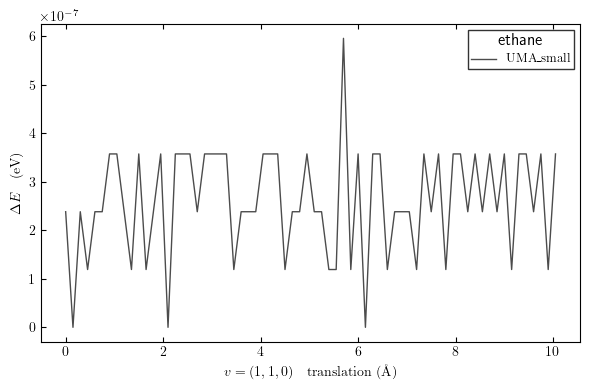

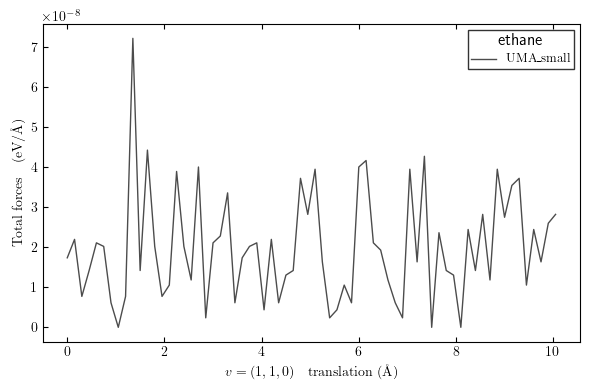

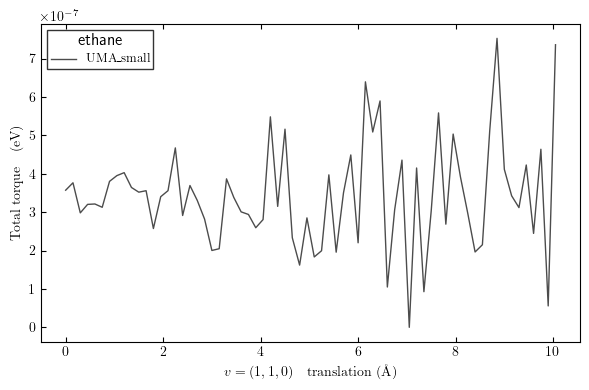

ethane
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 

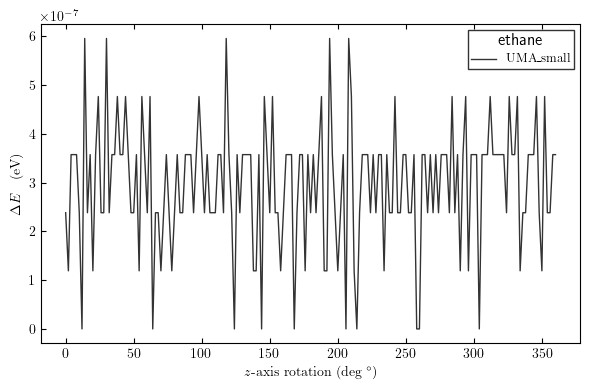

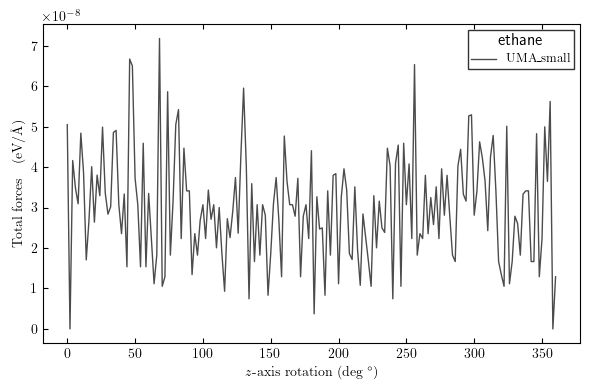

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-6319.212640307631, -6319.2126403672355, -6319.21264042684, -6319.212640307631, -6319.212640486445, -6319.212640248026, -6319.212640248026, -6319.2126403672355, -6319.2126403672355, -6319.212640248026, -6319.212640307631, -6319.212640248026, -6319.2126403672355, -6319.2126403672355, -6319.212640248026, -6319.21264042684, -6319.212640307631, -6319.212640307631, -6319.212640128817, 

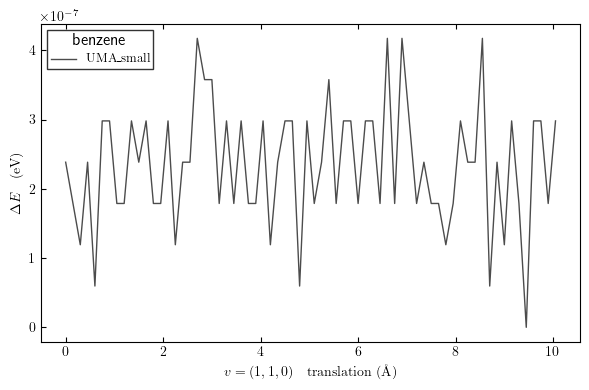

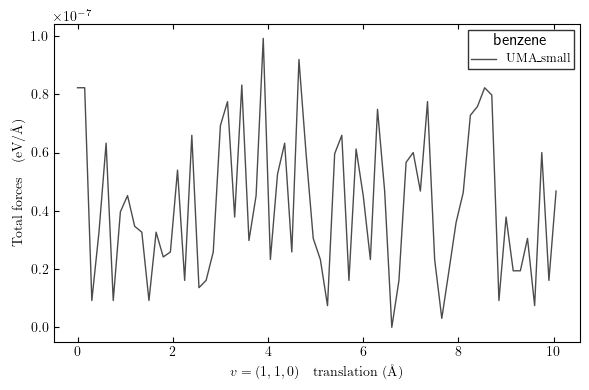

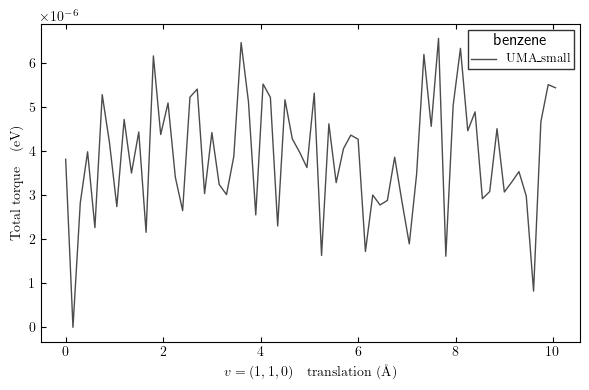

benzene
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

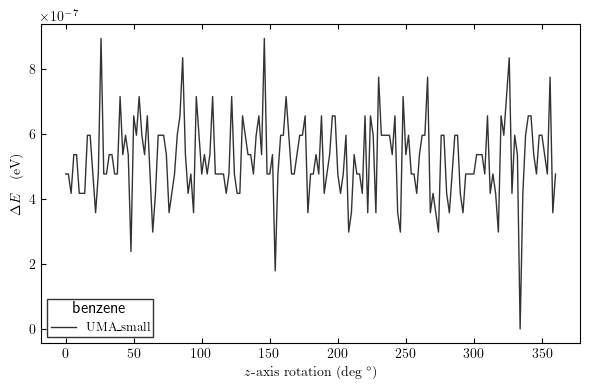

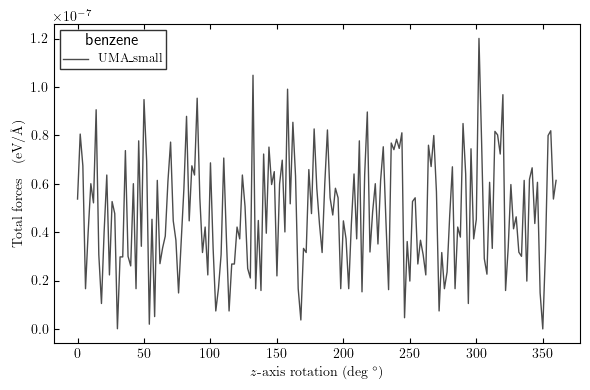

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-5132.575019757247, -5132.5750197125435, -5132.5750197125435, -5132.575020204282, -5132.575019675291, -5132.575019734895, -5132.5750197125435, -5132.575019734895, -5132.575019734895, -5132.575019675291, -5132.575020159578, -5132.575020248985, -5132.57502030859, -5132.575020330942, -5132.575019354916, -5132.575019652939, -5132.575019779599, -5132.575019734895, -5132.5750198019505, 

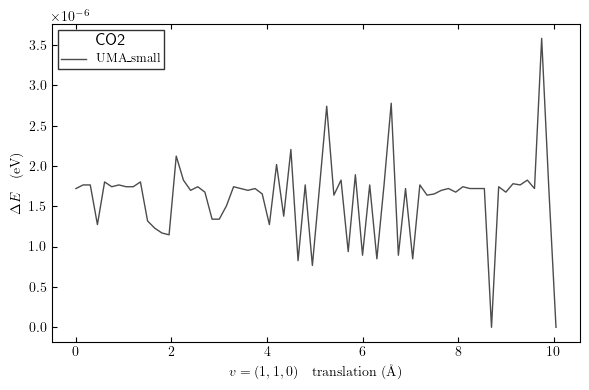

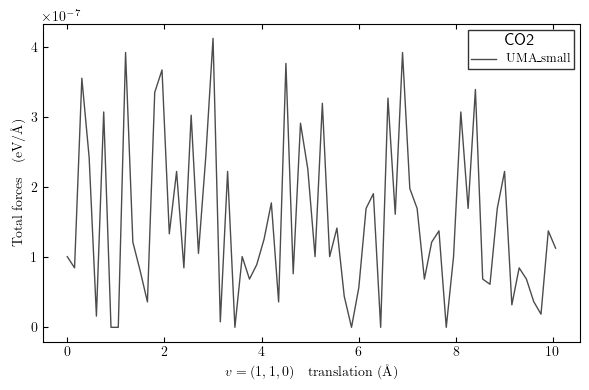

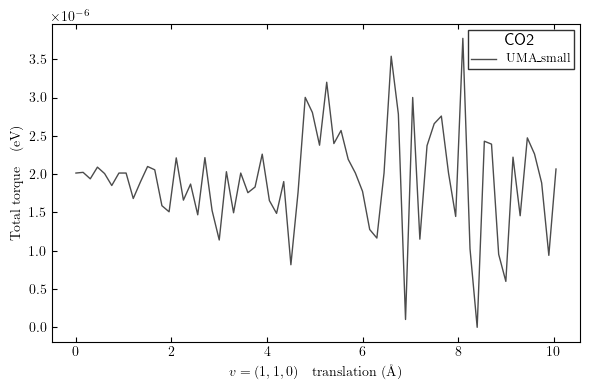

CO2
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360

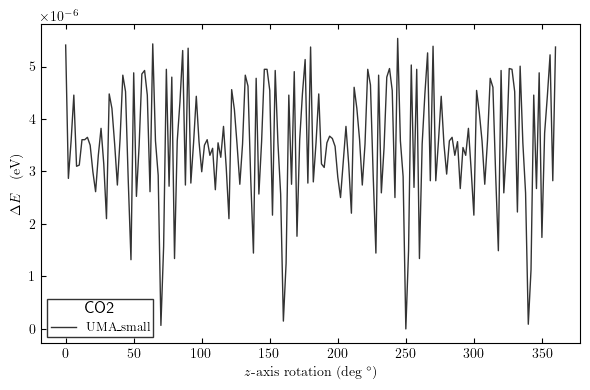

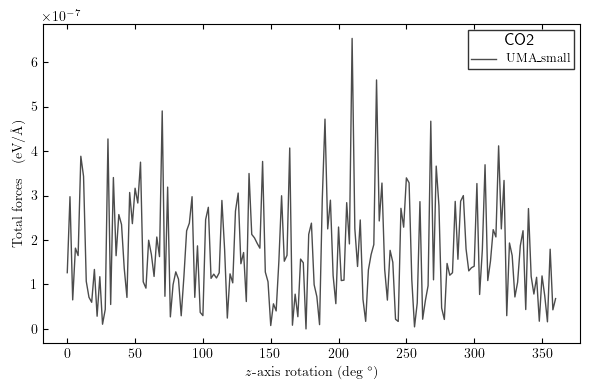

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4208.2526732830775, -4208.25267280624, -4208.25267280624, -4208.252673759915, -4208.25267280624, -4208.25267280624, -4208.252673759915, -4208.2526732830775, -4208.25267280624, -4208.252673759915, -4208.25267280624, -4208.25267280624, -4208.25267280624, -4208.25267280624, -4208.25267280624, -4208.252673759915, -4208.252673759915, -4208.2526732830775, -4208.252673759915, -4208.2526

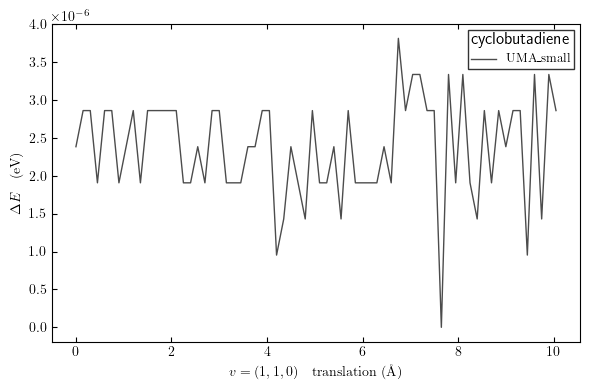

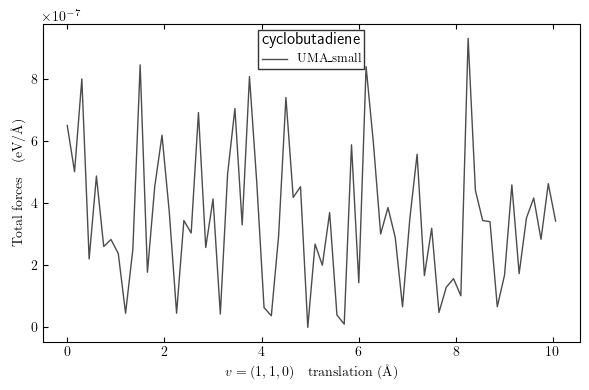

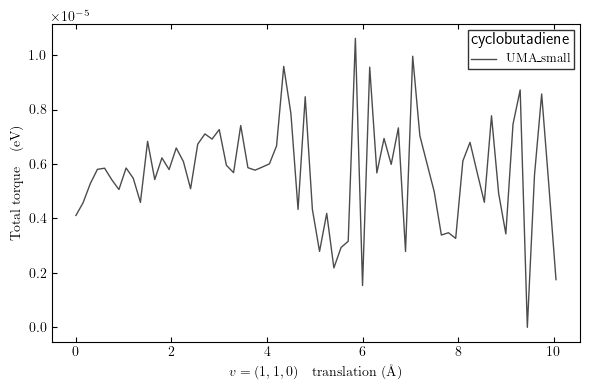

cyclobutadiene
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 35

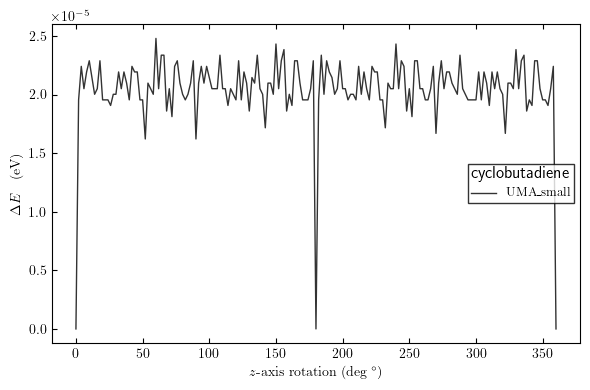

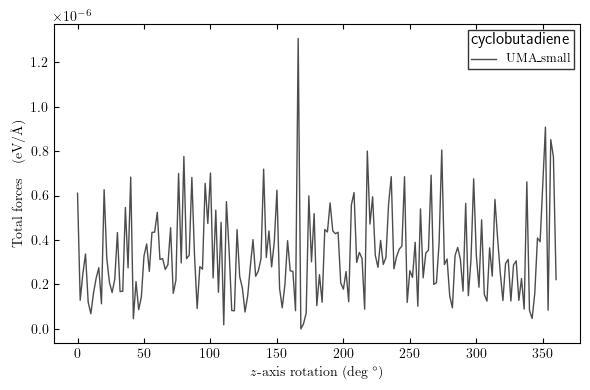

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4218.441126469623, -4218.441126529227, -4218.441126588832, -4218.441126529227, -4218.441126529227, -4218.441126529227, -4218.441126529227, -4218.441126648437, -4218.441126529227, -4218.441126529227, -4218.441126588832, -4218.441126410018, -4218.441126708041, -4218.441126529227, -4218.441126588832, -4218.441126708041, -4218.441126708041, -4218.441126529227, -4218.441126290809, -42

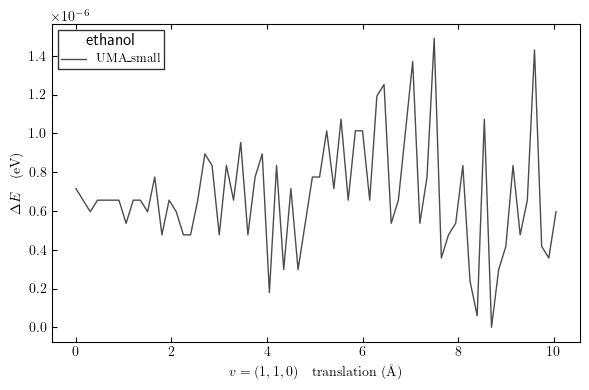

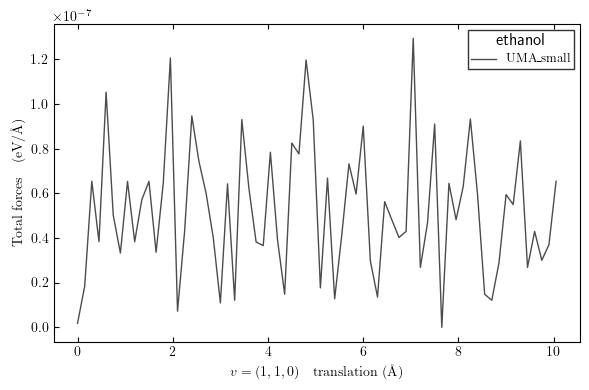

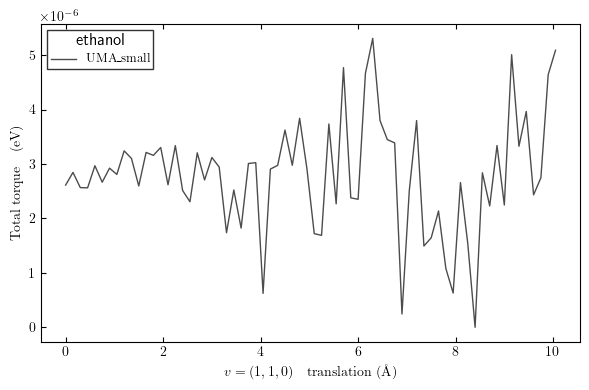

ethanol
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

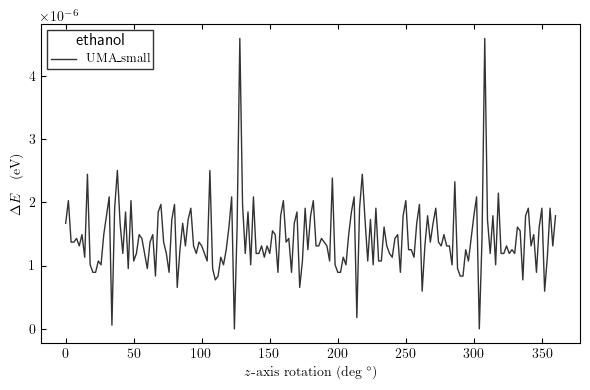

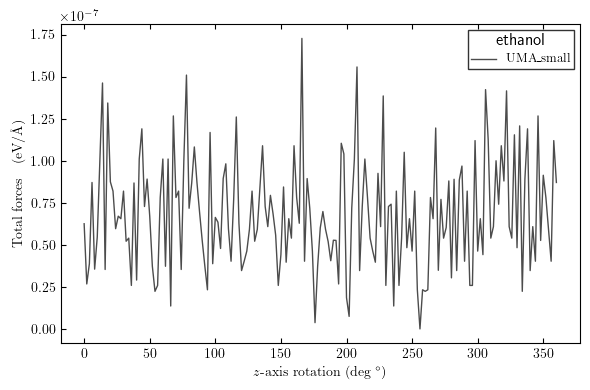

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4089.730249164888, -4089.7302477343765, -4089.730248688051, -4089.730249164888, -4089.730249164888, -4089.730248688051, -4089.730248688051, -4089.730248688051, -4089.730248688051, -4089.7302482112136, -4089.730248688051, -4089.730248688051, -4089.7302482112136, -4089.730248688051, -4089.7302482112136, -4089.730249164888, -4089.730248688051, -4089.730248688051, -4089.730248688051,

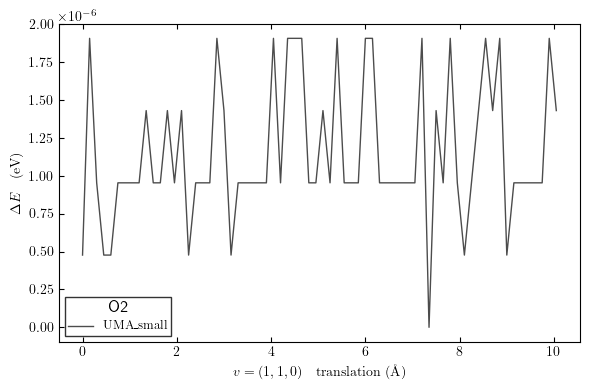

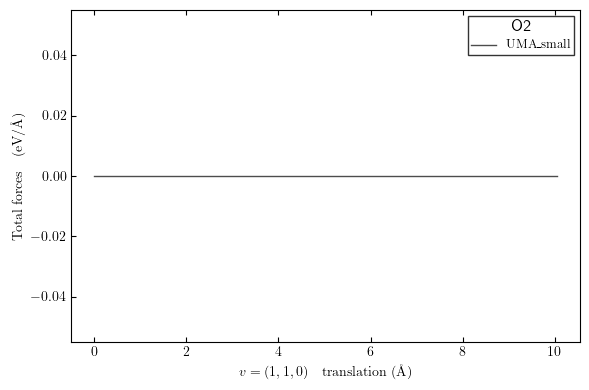

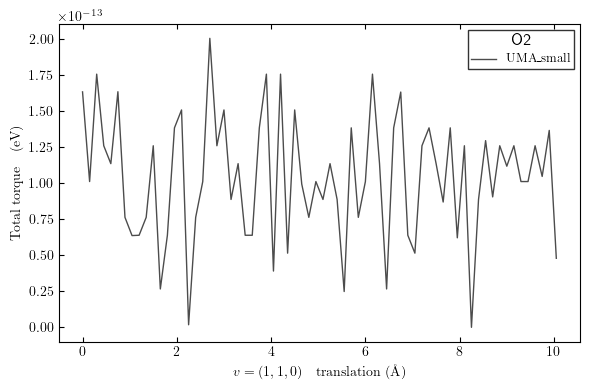

O2
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360.

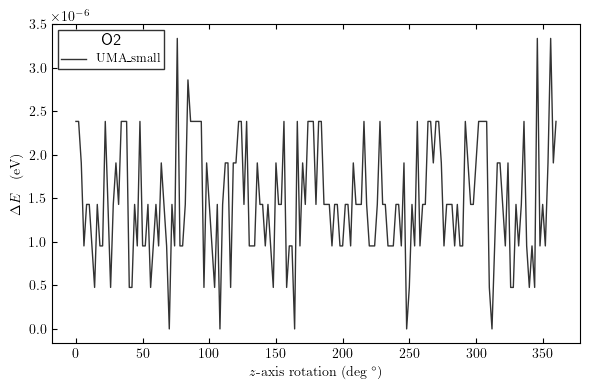

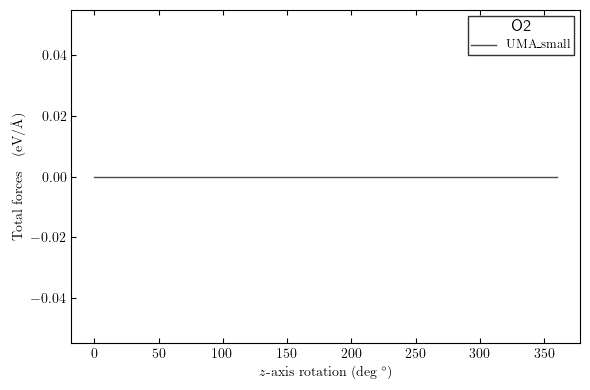

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-2079.862059725134, -2079.8620598145408, -2079.8620598145408, -2079.8620597996396, -2079.862059829442, -2079.862059725134, -2079.8620598145408, -2079.8620597996396, -2079.8620597996396, -2079.862059754936, -2079.8620597847384, -2079.862059829442, -2079.8620597698373, -2079.862059829442, -2079.8620597847384, -2079.8620596953315, -2079.862059844343, -2079.8620598145408, -2079.862059

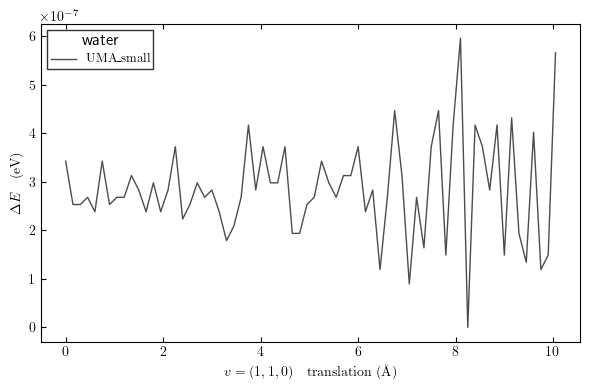

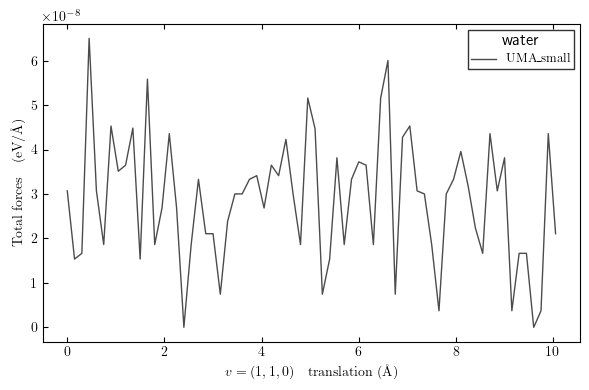

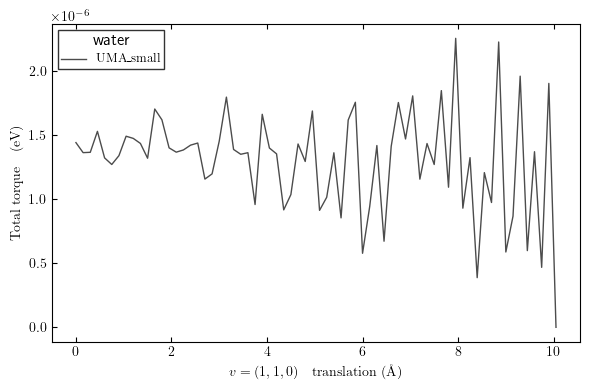

water
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 3

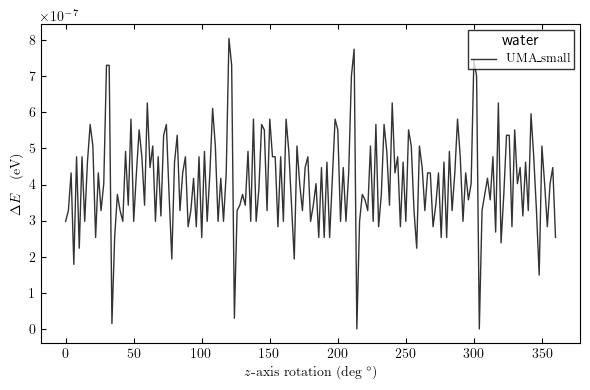

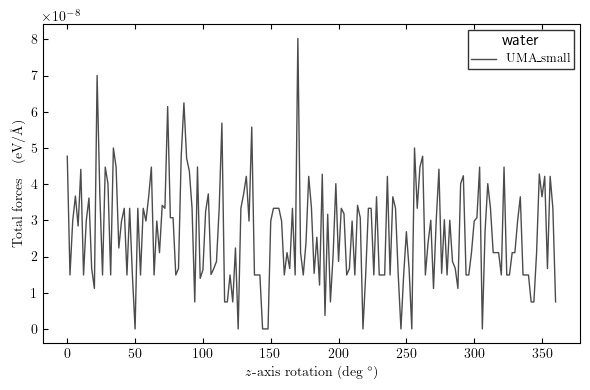

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 1 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-5287.951215154799, -5287.951215274008, -5287.951215154799, -5287.951215274008, -5287.951215095194, -5287.951215095194, -5287.951215274008, -5287.951215154799, -5287.951215393217, -5287.951215095194, -5287.951215095194, -5287.951214975985, -5287.951214975985, -5287.951215154799, -5287.951215154799, -5287.951215393217, -5287.951215333613, -5287.951214856776, -5287.95121491638, -528

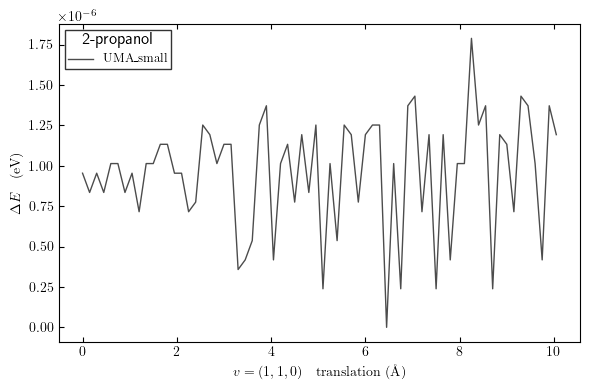

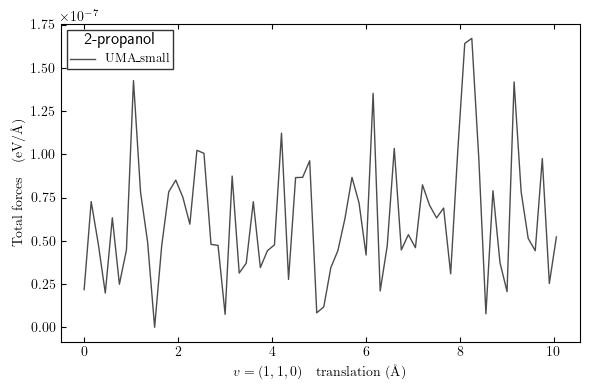

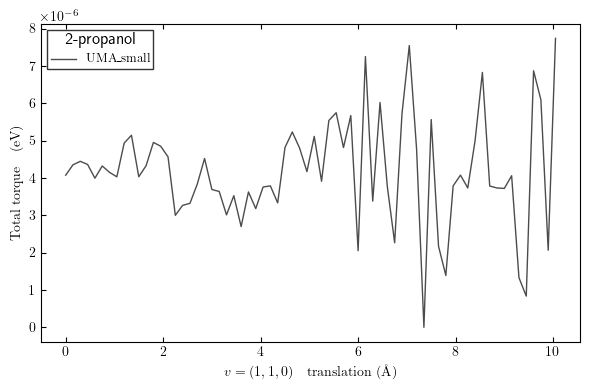

2-propanol
analyzing 180 rotationally different structures
using 1 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 3

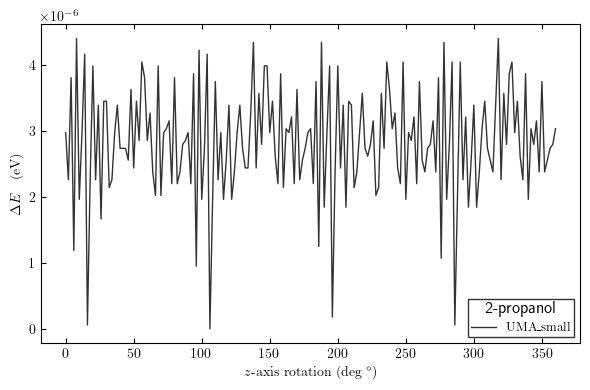

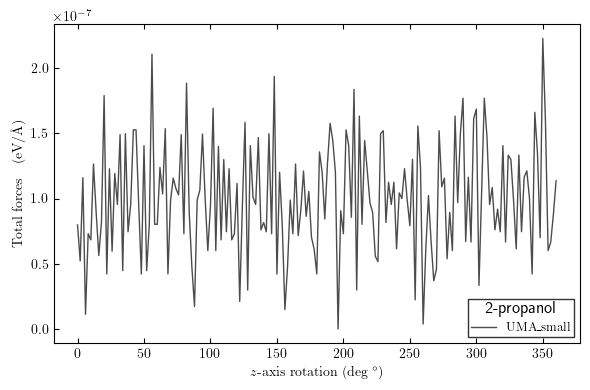

IndexError: list index out of range

In [ ]:
# molecule list (smiles)
mol_string_list = ['ethane', 'benzene', 'CO2', 'cyclobutadiene', 'ethanol', 'O2', 'water', '2-propanol']
mol_list = ['CC', 'C1=CC=CC=C1', 'C(=O)=O', 'C1=CC=C1', 'CCO', 'O=O', 'O', 'CCCO', 'CC(C)O']

# test options
trans_vector = (1,1,0)
# rotations are z-axis only

# fetch the molecule structures from pubchem via ASE
mol_ase_list = [pubchem_atoms_search(smiles=mol) for mol in mol_list]

for i in range(len(mol_ase_list)):
    evaluate_translation(mol_ase_list[i], calculator_list, mol_string_list[i], calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False)
    evaluate_rotation(mol_ase_list[i], calculator_list, calc_name=CALC_NAME, mol_name=mol_string_list[i], resolution=2)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.2 Å
using 7 models
scanning total displacements:
[ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]


2025-03-10 19:22:25.088 python[32467:2430819] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-10 19:22:25.088 python[32467:2430819] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2025-03-10 19:22:27.181 python[32512:2431353] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-10 19:22:27.181 python[32512:2431353] +[IMKInputSession subclass]: chose IMKInputSession_Modern


resulting energies:
[[-5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689922292, -5130.172689922292, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689820922, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689516811, -5130.172689516811, -5130.172689415441, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172690530514, -5130.172690530514, -5130.172690530514, -5130.172690530514, -5130.172689111329, -5130.172689111329, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172691442847, -5130.172689719552, -5130.172689719552, -5130.172689719552, -5130.172689719552

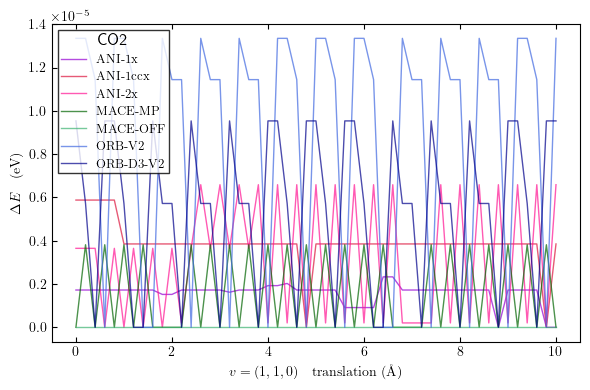

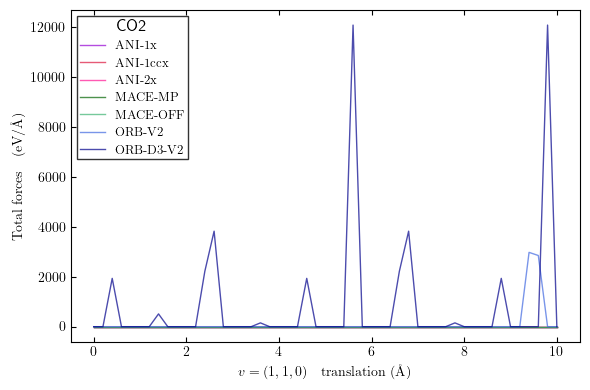

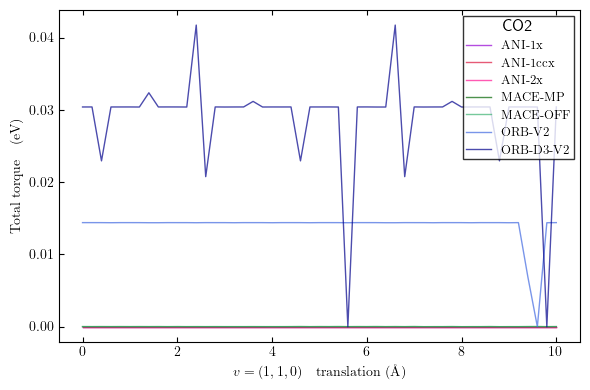

CO2
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360

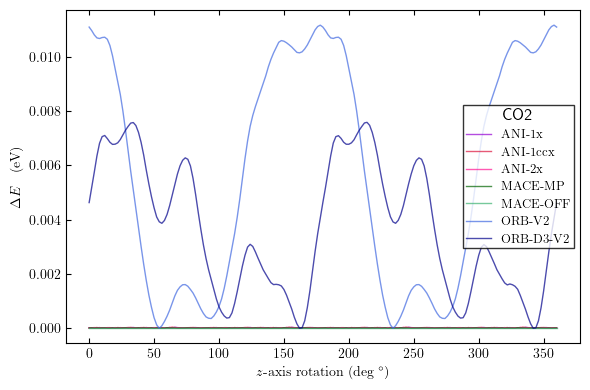

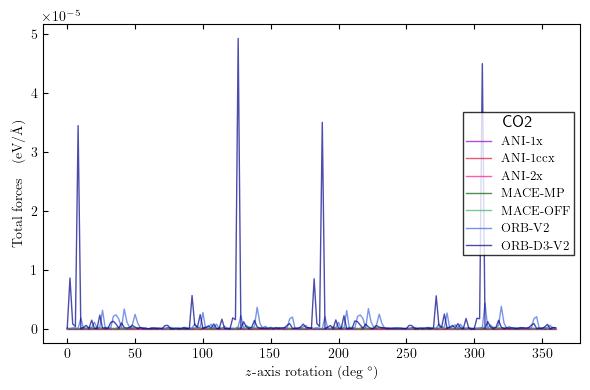

In [17]:
mol_name = 'CO2'
bond_name = 'CO'
molecule = pubchem_atoms_search(smiles='C(=O)=O')
view(molecule)

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.2, search_space=[0, 10], visualize=False)

evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
resulting energies:
[[-4087.7806662506287, -4087.7806658451473, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.780667061591, -4087.7806658451473, -4087.7806662506287, -4087.7806662506287, -4087.7806662506287, -4087.780667061591, -4087.7

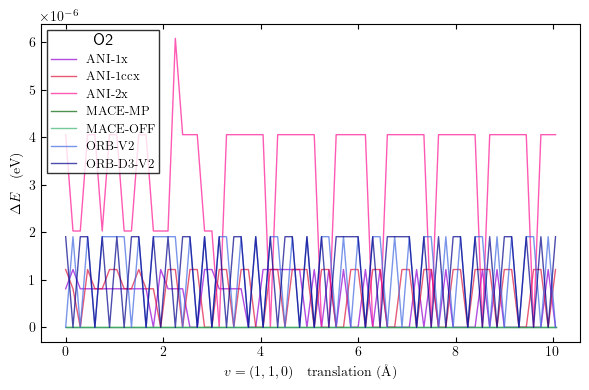

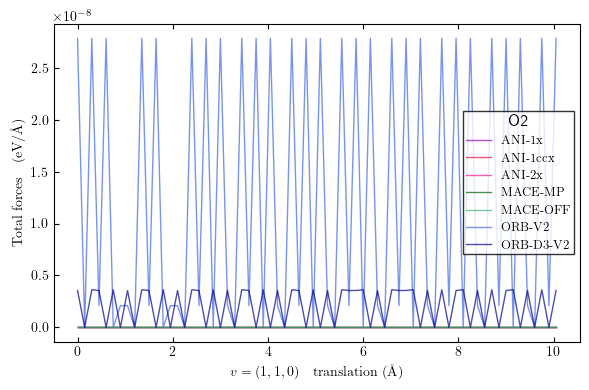

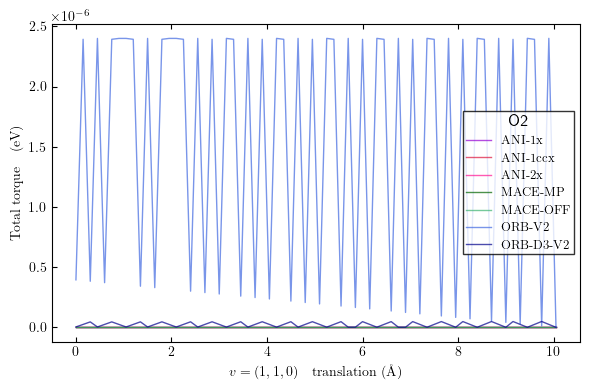

O2
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358. 360.

2025-03-10 19:21:02.832 python[32419:2430033] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-10 19:21:02.832 python[32419:2430033] +[IMKInputSession subclass]: chose IMKInputSession_Modern


resulting energies:
[[-4087.78066989996, -4087.7806711164035, -4087.78066341226, -4087.7806678725537, -4087.7806690889975, -4087.7806739547723, -4087.780667061591, -4087.7806678725537, -4087.7806682780347, -4087.7806646287036, -4087.78067314381, -4087.7806658451473, -4087.7806609793724, -4087.7806719273663, -4087.7806711164035, -4087.780671521885, -4087.7806646287036, -4087.7806747657346, -4087.7806658451473, -4087.780671521885, -4087.7806646287036, -4087.78066341226, -4087.7806658451473, -4087.780672332847, -4087.7806617903348, -4087.7806711164035, -4087.780660573891, -4087.7806630067785, -4087.7806617903348, -4087.7806593574473, -4087.7806727383286, -4087.7806674670724, -4087.780665034185, -4087.780678820547, -4087.7806711164035, -4087.7806565190785, -4087.780662195816, -4087.780662195816, -4087.7806678725537, -4087.780667061591, -4087.780665439666, -4087.7806690889975, -4087.7806682780347, -4087.78066341226, -4087.7806711164035, -4087.78066989996, -4087.7806711164035, -4087.78066341

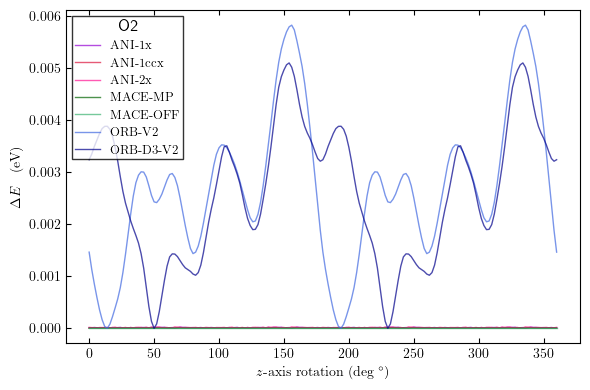

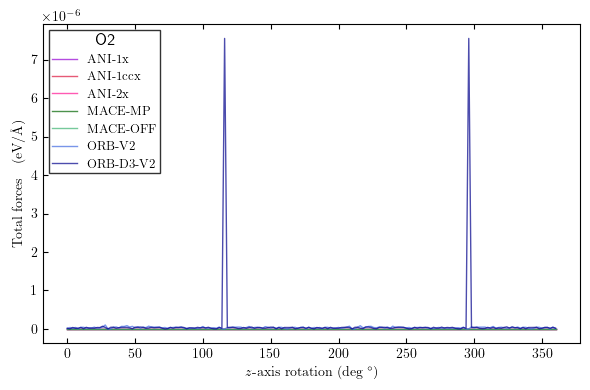

In [ ]:
mol_name = 'O2'
molecule = pubchem_atoms_search(smiles='O=O')
view(molecule)

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False)

evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2)

using unit translation vector	[0.70710678 0.70710678 0.        ]
analyzing translationally different structures with resolution 0.15 Å
using 7 models
scanning total displacements:
[ 0.    0.15  0.3   0.45  0.6   0.75  0.9   1.05  1.2   1.35  1.5   1.65
  1.8   1.95  2.1   2.25  2.4   2.55  2.7   2.85  3.    3.15  3.3   3.45
  3.6   3.75  3.9   4.05  4.2   4.35  4.5   4.65  4.8   4.95  5.1   5.25
  5.4   5.55  5.7   5.85  6.    6.15  6.3   6.45  6.6   6.75  6.9   7.05
  7.2   7.35  7.5   7.65  7.8   7.95  8.1   8.25  8.4   8.55  8.7   8.85
  9.    9.15  9.3   9.45  9.6   9.75  9.9  10.05]
<class 'torch.Tensor'>
torch.float32
<class 'torch.Tensor'>
torch.float32
torch.float64
<class 'torch.Tensor'>
torch.float32
<class 'torch.Tensor'>
torch.float32
torch.float64
<class 'torch.Tensor'>
torch.float32
<class 'torch.Tensor'>
torch.float32
torch.float64
<class 'torch.Tensor'>
torch.float32
<class 'torch.Tensor'>
torch.float32
torch.float64
<class 'torch.Tensor'>
torch.float32
<class 'torch.Te

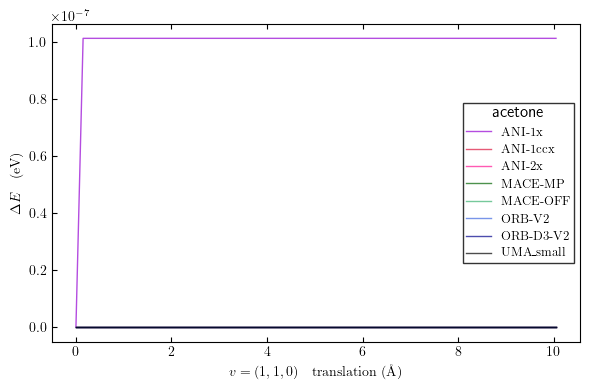

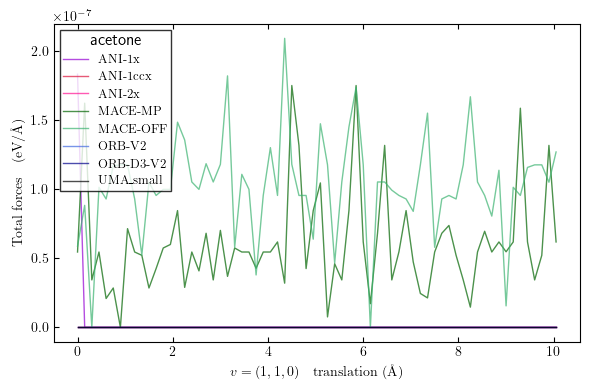

[-0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569 -0.37730569
 -0.37730569 -0.37730569]


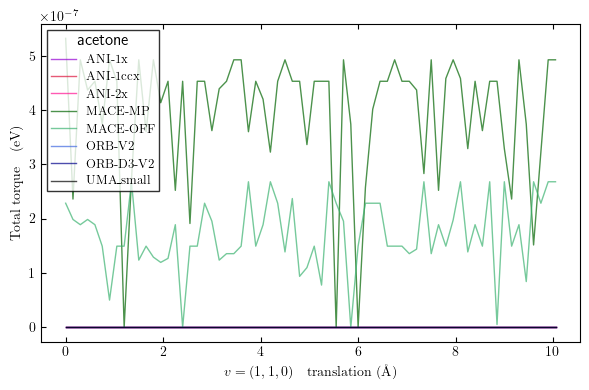

acetone
analyzing 180 rotationally different structures
using 7 models
scanning angles:
[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.
 252. 254. 256. 258. 260. 262. 264. 266. 268. 270. 272. 274. 276. 278.
 280. 282. 284. 286. 288. 290. 292. 294. 296. 298. 300. 302. 304. 306.
 308. 310. 312. 314. 316. 318. 320. 322. 324. 326. 328. 330. 332. 334.
 336. 338. 340. 342. 344. 346. 348. 350. 352. 354. 356. 358.

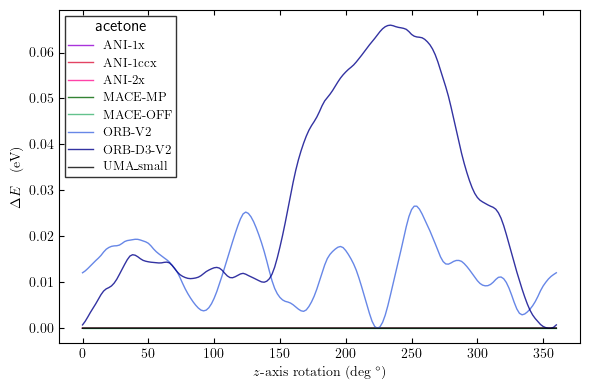

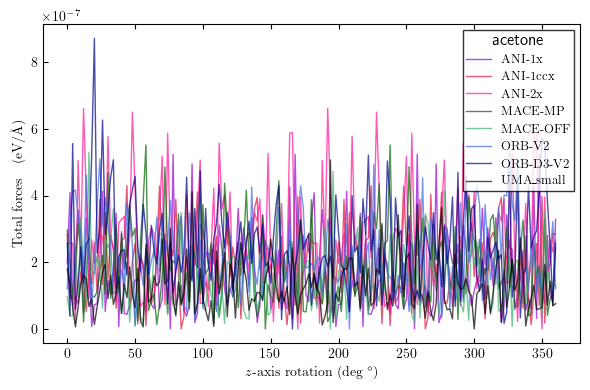

[-0.76500848 -0.76972085 -0.77351318 -0.7766101  -0.7790083  -0.78070945
 -0.78170877 -0.78200205 -0.7815993  -0.78048917 -0.77867652 -0.77616919
 -0.77296422 -0.76906791 -0.76448273 -0.7592183  -0.75327517 -0.74666572
 -0.73939661 -0.73147502 -0.72291359 -0.71372046 -0.70390911 -0.69348744
 -0.68247248 -0.67086533 -0.65871745 -0.64599366 -0.63273753 -0.61896309
 -0.60468322 -0.58991485 -0.57467638 -0.55899036 -0.542874   -0.5263419
 -0.5094201  -0.49213187 -0.47448549 -0.45651401 -0.43823695 -0.4196764
 -0.40085445 -0.38179725 -0.36252099 -0.34307145 -0.32341647 -0.30362882
 -0.28372811 -0.26373564 -0.24366088 -0.2235463  -0.20341292 -0.18327146
 -0.16316108 -0.14310701 -0.12311719 -0.10323429 -0.08347296 -0.06386007
 -0.04442072 -0.02513313 -0.00615228  0.01263103  0.03114227  0.04937879
  0.06729246  0.08488788  0.10212379  0.1189849   0.13545325  0.1514974
  0.1671138   0.18228467  0.19696877  0.2111722   0.22486838  0.23804659
  0.25067897  0.26274823  0.27426311  0.28518645  0.29

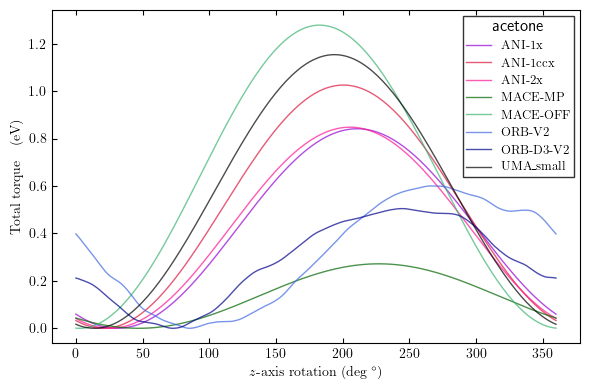

In [8]:
mol_name = 'acetone'
molecule = pubchem_atoms_search(smiles='CC(=O)C')
view(molecule)

trans_vector = (1, 1, 0)
evaluate_translation(molecule, calculator_list, mol_name, calc_name=CALC_NAME, trans_vector=trans_vector, resolution=0.15, search_space=[0, 10], visualize=False, UMA=False, compute_torque=True)
evaluate_rotation(molecule, calculator_list, calc_name=CALC_NAME, mol_name=mol_name, resolution=2, UMA=False, compute_torque=True)